<a href="https://colab.research.google.com/github/Aymanyah/Stat_app/blob/main/notebook/scouting_statapp_Raph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Scouting et Profilage de Joueurs ⚽📊**

Ce notebook est dédié à l’analyse et au **profilage de joueurs de football** à l’aide de statistiques avancées et de méthodes de **machine learning**. Nous allons :

- **Créer plusieurs indices de performance** afin de résumer les différentes dimensions du jeu d’un joueur (*offensive, création, défense, finition*) à partir de statistiques brutes.

- **Vérifier la pertinence de ces indices** en utilisant un modèle de **régression logistique** et une **matrice de confusion**, afin d’évaluer si ces indices permettent de prédire correctement le poste d’un joueur (*attaquant, milieu, défenseur*).

- **Développer un algorithme de scouting** basé sur la méthode **K-Nearest Neighbors (KNN)** afin d’identifier les **20 joueurs les plus similaires** à un joueur donné à partir de leurs profils statistiques.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import re
import unicodedata
from sklearn.preprocessing import StandardScaler

In [3]:
import pandas as pd

#url = "https://raw.githubusercontent.com/Aymanyah/Stat_app/main/data/clean/dataset_aggregated.csv"
#f = pd.read_csv(url)

#df.head()

## 🧹 Nettoyage et préparation du dataset

Avant toute analyse, une étape essentielle consiste à **nettoyer et préparer les données** afin de garantir la fiabilité des résultats.

Cette étape inclut notamment :

- **La suppression des valeurs manquantes ou incohérentes** dans certaines variables statistiques.
- **Le nettoyage des noms de colonnes et des encodages** afin d’éviter les problèmes liés aux caractères spéciaux.
- **La gestion des doublons de joueurs**, notamment lorsqu’un joueur apparaît plusieurs fois dans différentes compétitions.
- **Supression saison 2021/2022**, représente la même que 2020/2021
- **La sélection des joueurs ayant un temps de jeu suffisant**, afin d’éviter les biais liés à des statistiques peu représentatives (ex : joueurs ayant très peu joué).
- **La transformation et normalisation des variables**, afin de rendre les statistiques comparables entre joueurs et utilisables dans les modèles de machine learning.

Une fois ces étapes réalisées, le dataset est prêt pour la **construction des indices de performance**, première étape de l’analyse.

In [4]:
# --- 1) RECONVERTIR LES CHAÎNES EN UTF-8 CORRECT ---
# Nettoyer les noms de colonnes
df = pd.read_csv("all_leagues_merged_transformed.csv", encoding="utf8")

def fix_text(s):
    if isinstance(s, str):
        try:
            # On réencode et on décode pour corriger les caractères bizarres
            return s.encode('latin1').decode('utf-8')
        except:
            return s
    return s

# Appliquer à toutes les colonnes texte
text_cols = ["player", "team", "league", "nation", "pos"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(fix_text)

# --- 2) Nettoyage simple des colonnes ---
df.columns = [fix_text(col).strip() for col in df.columns]

# Supprimer les doublons exacts
df_clean = df.drop_duplicates()

# --- 1) COLONNES NUMÉRIQUES ---
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["season"]]

# --- 2) DÉFINITION D'UNE FONCTION D'AGRÉGATION INTELLIGENTE ---
def smart_agg(col):
    if "percent" in col.lower() or "%" in col or "ratio" in col.lower():
        return "mean"
    if col in ["Minutes de jeu", "G", "G-PK", "Assists", "Tirs", "Tirs cadrés"]:
        return "sum"
    return "mean"

agg_dict = {col: smart_agg(col) for col in numeric_cols}

# --- 3) AJOUT DES COLONNES CATEGORIELLES ---
# On prend "last" pour team, league, nation, pos
categorical_cols = [c for c in ["team", "league", "nation", "pos"] if c in df_clean.columns]
for col in categorical_cols:
    agg_dict[col] = "last"

# --- 4) AGGRÉGATION PAR JOUEUR + SAISON ---
df_grouped = df_clean.groupby(["player", "season"]).agg(agg_dict).reset_index()

# --- 5) PIVOT DES STATISTIQUES NUMÉRIQUES ---
df_stats = df_grouped.pivot(index="player", columns="season", values=numeric_cols)
df_stats.columns = [f"{stat}_{season}" for stat, season in df_stats.columns]
df_stats = df_stats.reset_index()

# --- 6) PIVOT DES COLONNES CATEGORIELLES ---
df_cats = {}
for col in categorical_cols:
    df_cat = df_grouped.pivot(index="player", columns="season", values=col)
    df_cat.columns = [f"{col}_{season}" for season in df_cat.columns]
    df_cats[col] = df_cat.reset_index()

# --- 7) FUSION DE TOUTES LES COLONNES ---
df_final = df_stats
for col, df_cat in df_cats.items():
    df_final = df_final.merge(df_cat, on="player", how="left")

# --- 8) SUPPRESSION INTELLIGENTE DES COLONNES 2021 POUR LES STATS NUMÉRIQUES ---
for col in df_final.columns:
    if col.endswith("_2020.0"):
        col_2021 = col.replace("_2020.0", "_2021.0")
        if col_2021 in df_final.columns:
            df_final[col] = df_final[col].fillna(df_final[col_2021])
            df_final = df_final.drop(columns=[col_2021])

# --- 9) GARDER UNE SEULE COLONNE BORN ET POS ---
born_cols = [c for c in df_final.columns if c.startswith("born_")]
if born_cols:
    df_final["born"] = df_final[born_cols].bfill(axis=1).iloc[:, 0]
    df_final = df_final.drop(columns=born_cols)

pos_cols = [c for c in df_final.columns if c.startswith("pos_")]
if pos_cols:
    df_final["pos"] = df_final[pos_cols].bfill(axis=1).iloc[:, 0]
    df_final = df_final.drop(columns=pos_cols)


# --- 10) METTRE EN décimale LES VALEURS EN POURCENTAGE ---
percent_cols = [c for c in df_final.columns if "%" in c]
for col in percent_cols:
    if df_final[col].mean(skipna=True) > 1:
        df_final[col] = df_final[col] / 100


print(df_final.head())


             player  age_2020  age_2021  age_2022  age_2023  \
0    Aaron Connolly       NaN      20.0       NaN       NaN   
1   Aaron Cresswell      30.0      30.0      32.0      33.0   
2      Aaron Hickey      18.0      18.0      20.0      21.0   
3  Aaron Leya Iseka      22.0       NaN       NaN       NaN   
4     Aaron Malouda       NaN       NaN       NaN      17.0   

   Minutes de jeu_2020  Minutes de jeu_2021  Minutes de jeu_2022  \
0                  NaN                791.0                  NaN   
1               3170.0               3170.0               2235.0   
2                758.0                758.0               1916.0   
3               1008.0                  NaN                  NaN   
4                  NaN                  NaN                  NaN   

   Minutes de jeu_2023  # 90 min jouées_2020  ...         league_2020  \
0                  NaN                   NaN  ...                 NaN   
1                436.0                  35.2  ...  ENG-Premier Lea

In [5]:
df_final[
    df_final["player"].str.contains("Kylian Mbappé", case=False, na=False)
][[
    "player",
    "age_2021",
    "team_2023",
    "league_2023",
    "pos",
    "Minutes de jeu_2023",
    "G_2023",
    "xG_2023",
    "A_2023",
    "Passes menant à un but_2023",
    "Valeur marchande (euros)_2023",
    "% passes réussies_2023"
]]

,player,age_2021,team_2023,league_2023,pos,Minutes de jeu_2023,G_2023,xG_2023,A_2023,Passes menant à un but_2023,Valeur marchande (euros)_2023,% passes réussies_2023
2217,Kylian Mbappé,21.0,Paris S-G,FRA-Ligue 1,FW,2158.0,1.13,0.87,0.29,1.666667,180000000.0,0.83


In [6]:
numeric_cols = df_final.select_dtypes(include=[np.number]).columns

# Retirer le suffixe saison (_2020, _2022, etc.) pour ne garder que le nom de la stat
stat_names = set(col.split("_")[0] for col in numeric_cols)

# Afficher toutes les stats uniques
print(sorted(stat_names))

['# 90 min jouées', '% dribble  réussis', '% duels aériens gagnés', '% passes courtes réussies', '% passes longues réussies', '% passes moyennes réussies', '% passes réussies', 'A', 'Blocs totaux', 'Chevauchée avant  >5m', 'Distance totale des passes > 10m avant effectuées', 'Dribbles subis perdus', 'Dégagements', 'Erreurs menant à un tir adverse', 'G', 'G+A', 'G+A-PK', 'G-PK', 'Interceptions', 'Minutes de jeu', "Passes > 10m vers l'avant reçues", 'Passes avant >10m', 'Passes menant à un but', 'Passes reçues', 'Tacles réussis + interceptions', 'Tacles réussis qui gagnent la balle', 'Tirs', 'Tirs cadrés', 'Touches ballon en jeu', 'Valeur marchande (euros)', 'age', 'born', 'npxG', 'npxG+xAG', 'xAG', 'xG', 'xG / Tir', 'xG+xAG']


###⚽ Construction et validation exploratoire d’un indice offensif synthétique

Dans un premier temps, l’objectif consiste à construire un indicateur synthétique permettant de résumer la contribution offensive globale des joueurs à partir de statistiques individuelles issues de la saison 2023.
Les bases de données footballistiques contiennent un grand nombre de variables hétérogènes (buts, tirs, expected goals, actions décisives, etc.), rendant l’analyse comparative directe difficile et peu lisible.

Cette étape consiste à observer la distribution de l’indice offensif et à identifier les profils dominants à travers des visualisations interactives.
L’objectif est double : vérifier la cohérence économique et sportive des résultats obtenus et s’assurer que la pondération retenue met effectivement en avant les joueurs reconnus pour leur impact offensif.

In [7]:
import pandas as pd
import plotly.graph_objects as go

# -------------------------------
# 1️⃣ Sélection joueurs 2023 et min de jeu
# -------------------------------
df_last2 = df_final[df_final["Minutes de jeu_2023"] >= 900.0].copy()

# Coefficients par ligue
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}
df_last2["uefa_coefficient_2023"] = df_last2["league_2023"].map(coeff_dict)

# Réduire le poids du % de passes réussies
df_last2["passes réussies ratio"] = df_last2["% passes réussies_2023"] / 100

# -------------------------------
# 2️⃣ Calcul Offensive Strength Index (OSI)
# -------------------------------
df_last2["OSI"] = (
    df_last2["G-PK_2023"] * 0.05
    +df_last2["G_2023"] * 2
    + (df_last2["G_2023"] - df_last2["G-PK_2023"]) * 0.05
    + df_last2["Tirs_2023"] * 0.05
    + df_last2["Tirs cadrés_2023"] * 1.2
    + df_last2["xG_2023"] * 1.2
    + df_last2["xG / Tir_2023"] * 0.5
    + df_last2["% duels aériens gagnés_2023"] * 0.01
    + df_last2["Passes menant à un but_2023"] * 0.5
    + df_last2["uefa_coefficient_2023"]
)

# Normalisation 0–100%
df_last2["Off Index"] = (
    (df_last2["OSI"] - df_last2["OSI"].min())
    / (df_last2["OSI"].max() - df_last2["OSI"].min())
) * 100

# -------------------------------
# 3️⃣ Tri et sélection Top 20 attaquants et milieux
# -------------------------------
df_sorted = df_last2.sort_values("Off Index", ascending=False)
df_attack = df_sorted[df_sorted["pos"] == "FW"].head(20)
df_mid = df_sorted[df_sorted["pos"] == "MF"].head(20)

# -------------------------------
# 4️⃣ Fonction Plot Interactif
# -------------------------------
def plot_top20_interactive_off(df_subset, title="Top 20 Players – Off Index", stats_cols=None, cmap_name="Reds"):
    players = df_subset["player"]
    values = df_subset["Off Index"]

    hover_texts = []
    for i, row in df_subset.iterrows():
        hover_text = f"<b>Off Index : {row['Off Index']:.1f}%</b><br>"
        hover_text += f"<b>{row['player']}</b><br>"
        hover_text += f"Poste : {row['pos']}<br>"
        hover_text += f"Club : {row['team_2023']}<br>"
        hover_text += f"Ligue : {row['league_2023']}<br>"
        hover_text += f"Age : {row['age_2023']}<br><br>"
        hover_text += "<b>Stats utilisées :</b><br>"
        for col in stats_cols:
            if col in row:
                clean_col = col.replace("_2023", "")  # pour enlever le _2023 dans l'affichage
                hover_text += f"{clean_col}: {row[col]}<br>"
        hover_texts.append(hover_text)

    fig = go.Figure(go.Bar(
        x=values,
        y=players,
        orientation='h',
        text=[f"{v:.1f}%" for v in values],
        textposition='outside',
        marker=dict(
            color=values,
            colorscale=cmap_name,
            showscale=True
        ),
        hoverinfo='text',
        hovertext=hover_texts
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Offensive Strength Index (%)",
        yaxis=dict(autorange="reversed"),  # meilleur en haut
        height=600,
        margin=dict(l=150, r=50, t=50, b=50)
    )

    fig.show()

# -------------------------------
# 5️⃣ Colonnes utilisées pour le hover
# -------------------------------
stats_cols_off = [
    "G-PK_2023", "G_2023", "Tirs_2023", "Tirs cadrés_2023",
    "xG_2023", "xG / Tir_2023", "% duels aériens gagnés_2023",
    "Passes menant à un but_2023", "uefa_coefficient_2023"
]

# -------------------------------
# 6️⃣ Plot interactif
# -------------------------------
# Attaquants
plot_top20_interactive_off(df_attack, title="Top 20 Attackers – Off Index", stats_cols=stats_cols_off, cmap_name="Reds")

# Milieux
plot_top20_interactive_off(df_mid, title="Top 20 Midfielders – Off Index", stats_cols=stats_cols_off, cmap_name="Purples")


In [8]:
# Trouver 20 meilleurs  millieux par rapp Creativity Index

# Joueur avec min 10 matchs joués sur la saison
df_last2 = df_final[df_final["Minutes de jeu_2023"] >= 900.0].copy()

# Réduire le poids du % de passes réussies
df_last2["passes réussies ratio_2023"] = df_last2["% passes réussies_2023"] / 100

# Ajouter la colonne coefficient dans ton df
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}
df_last2["uefa_coefficient_2023"] = df_last2["league_2023"].map(coeff_dict)

# Calcul de l'indice Mil Index
df_last2["MSI"] = (
    # Création / offensif
    df_last2["A_2023"] * 2
    + df_last2["G_2023"] * 0.5
    + df_last2["passes réussies ratio_2023"] * 3
    + df_last2["Passes menant à un but_2023"] * 2
    + df_last2["Passes avant >10m_2023"] * 0.5
    + df_last2["% passes longues réussies_2023"] * 0.6
    + df_last2["xAG_2023"] * 1
    + df_last2["% dribble  réussis_2023"] * 0.5

    # Défensif
    + df_last2["Interceptions_2023"] * 1.8
    + df_last2["Tacles réussis qui gagnent la balle_2023"] * 1.5
    + df_last2["Dégagements_2023"] * 1
    + df_last2["Blocs totaux_2023"] * 1.5

    # Participation / volume
    + df_last2["Minutes de jeu_2023"] * 0.05
    + df_last2["Touches ballon en jeu_2023"] * 1
    + df_last2["Chevauchée avant  >5m_2023"] * 0.5
    + df_last2["Distance totale des passes > 10m avant effectuées_2023"] * 0.5

    # Poids ligue
    + df_last2["uefa_coefficient_2023"]
)

# Normalisation 0–100%
df_last2["Mil Index"] = (
    (df_last2["MSI"] - df_last2["MSI"].min())
    / (df_last2["MSI"].max() - df_last2["MSI"].min())
) * 100

# Tri
df_sorted = df_last2.sort_values("Mil Index", ascending=False)

# Sélection des 20 meilleurs milieux
df_mid = df_sorted[df_sorted["pos"] == "MF"].head(20)


# ----- Plot interactif -----
import plotly.graph_objects as go

def plot_top20_interactive(df_subset, title="Top 20 Midfielders – Mil Index", stats_cols=None):
    players = df_subset["player"]
    values = df_subset["Mil Index"]

    hover_texts = []
    for i, row in df_subset.iterrows():
        hover_text = f"<b>Mil Index : {row['Mil Index']:.1f}%</b><br>"
        hover_text += f"<b>{row['player']}</b><br>"
        hover_text += f"Poste : {row['pos']}<br>"
        hover_text += f"Club : {row['team_2023']}<br>"
        hover_text += f"Ligue : {row['league_2023']}<br>"
        hover_text += f"Age : {row['age_2023']}<br><br>"
        hover_text += "<b>Stats utilisées :</b><br>"
        for col in stats_cols:
            if col in row:
                clean_name = col.replace("_2023", "")
                hover_text += f"{clean_name}: {row[col]}<br>"
        hover_texts.append(hover_text)

    fig = go.Figure(go.Bar(
        x=values,
        y=players,
        orientation='h',
        text=[f"{v:.1f}%" for v in values],
        textposition='outside',
        marker=dict(
            color=values,
            colorscale='Oranges',
            showscale=True
        ),
        hoverinfo='text',
        hovertext=hover_texts
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Mil Index (%)",
        yaxis=dict(autorange="reversed"),
        height=600,
        margin=dict(l=150, r=50, t=50, b=50)
    )

    fig.show()


# Colonnes utilisées pour MSI
stats_cols_2023 = [
    "A_2023", "G_2023", "passes réussies ratio_2023", "Passes menant à un but_2023", "Passes avant >10m_2023",
    "% passes longues réussies_2023", "xAG_2023", "% dribble  réussis_2023",
    "Interceptions_2023", "Tacles réussis qui gagnent la balle_2023", "Dégagements_2023", "Blocs totaux_2023",
    "Minutes de jeu_2023", "Touches ballon en jeu_2023", "Chevauchée avant  >5m_2023", "Distance totale des passes > 10m avant effectuées_2023"
]

# Plot interactif
plot_top20_interactive(df_mid, stats_cols=stats_cols_2023)

In [9]:
# Joueur avec min 10 matchs joués sur la saison
df_last2 = df_final[df_final["Minutes de jeu_2023"] >= 900].copy()

# Réduire le poids du % de passes réussies
df_last2["passes réussies ratio_2023"] = df_last2["% passes réussies_2023"] / 100

# Ajouter la colonne coefficient
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}
df_last2["uefa_coefficient_2023"] = df_last2["league_2023"].map(coeff_dict)

defensive_cols = [
    "Tacles réussis qui gagnent la balle_2023",
    "Tacles réussis + interceptions_2023",
    "Interceptions_2023",
    "Blocs totaux_2023",
    "Dégagements_2023",
    "% duels aériens gagnés_2023",
    "passes réussies ratio_2023",
    "% passes longues réussies_2023",
    "Minutes de jeu_2023",
    "Dribbles subis perdus_2023",
    "Erreurs menant à un tir adverse_2023",
    "uefa_coefficient_2023"
]

#Puis tu appliques les poids après standardisation :
df_last2["DSI"] = (
    df_last2["Tacles réussis qui gagnent la balle_2023"] * 4
    + df_last2["Tacles réussis + interceptions_2023"] * 3
    + df_last2["Interceptions_2023"] * 2
    + df_last2["Blocs totaux_2023"] * 1
    + df_last2["Dégagements_2023"] * 0.1
    + df_last2["% duels aériens gagnés_2023"] * 1
    + df_last2["passes réussies ratio_2023"] * 2
    + df_last2["% passes longues réussies_2023"] * 2
    + df_last2["uefa_coefficient_2023"]
    - df_last2["Dribbles subis perdus_2023"] * 1.2
    - df_last2["Erreurs menant à un tir adverse_2023"] * 3
)
# Normalisation 0–100%
df_last2["Def Index"] = (
    (df_last2["DSI"] - df_last2["DSI"].min())
    / (df_last2["DSI"].max() - df_last2["DSI"].min())
) * 100

# Tri
df_sorted = df_last2.sort_values("Def Index", ascending=False)

# Sélection défenseurs et milieux
df_def = df_sorted[df_sorted["pos"] == "DF"].head(20)
df_mid = df_sorted[df_sorted["pos"] == "MF"].head(20)


# ----- Plot interactif -----
import plotly.graph_objects as go

def plot_top20_interactive_def(df_subset, title="Top 20 Defenders – Def Index", stats_cols=None, cmap_name="Greens"):
    players = df_subset["player"]
    values = df_subset["Def Index"]

    hover_texts = []
    for i, row in df_subset.iterrows():
        hover_text = f"<b>Def Index : {row['Def Index']:.1f}%</b><br>"
        hover_text += f"<b>{row['player']}</b><br>"
        hover_text += f"Poste : {row['pos']}<br>"
        hover_text += f"Club : {row['team_2023']}<br>"
        hover_text += f"Ligue : {row['league_2023']}<br>"
        hover_text += f"Age : {row['age_2023']}<br><br>"
        hover_text += "<b>Stats utilisées :</b><br>"
        for col in stats_cols:
            if col in row:
                clean_name = col.replace("_2023", "")
                hover_text += f"{clean_name}: {row[col]}<br>"
        hover_texts.append(hover_text)

    fig = go.Figure(go.Bar(
        x=values,
        y=players,
        orientation='h',
        text=[f"{v:.1f}%" for v in values],
        textposition='outside',
        marker=dict(
            color=values,
            colorscale=cmap_name,
            showscale=True
        ),
        hoverinfo='text',
        hovertext=hover_texts
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Defensive Strength Index (%)",
        yaxis=dict(autorange="reversed"),
        height=600,
        margin=dict(l=150, r=50, t=50, b=50)
    )

    fig.show()


# Plot interactif défenseurs
plot_top20_interactive_def(df_def, title="Top 20 Defenders – Def Index", stats_cols=defensive_cols, cmap_name="Blues")

# Plot interactif milieux
plot_top20_interactive_def(df_mid, title="Top 20 Midfielders – Def Index", stats_cols=defensive_cols, cmap_name="Greens")

In [10]:
import pandas as pd
import plotly.graph_objects as go

# -------------------------------
# 1️⃣ Sélection joueurs 2023 et min de jeu
# -------------------------------
df_last2 = df_final[df_final["Minutes de jeu_2023"] >= 900.0].copy()

# Coefficients par ligue
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}
df_last2["uefa_coefficient_2023"] = df_last2["league_2023"].map(coeff_dict)



# -------------------------------
# 2️⃣ Calcul Player EFF Index (OSI)
# -------------------------------
df_last2["PEI"] = (
    df_last2["G_2023"] * 2
    + df_last2["A_2023"] * 1.5
    + df_last2["Tirs cadrés_2023"] * 0.05
    + df_last2["Passes menant à un but_2023"] * 0.1
    + df_last2["% passes réussies_2023"] * 1.2
    + df_last2["uefa_coefficient_2023"]
)

# Normalisation 0–100%
df_last2["PEIndex"] = (
    (df_last2["PEI"] - df_last2["PEI"].min())
    / (df_last2["PEI"].max() - df_last2["PEI"].min())
) * 100

# -------------------------------
# 3️⃣ Tri et sélection Top 20 attaquants et milieux
# -------------------------------
df_sorted = df_last2.sort_values("PEIndex", ascending=False)
top20_players = df_sorted.head(20)
# -------------------------------
# 4️⃣ Fonction Plot Interactif
# -------------------------------
def plot_top20_interactive_off(df_subset, title="Top 20 Players – Player Eff Index", stats_cols=None, cmap_name="Reds"):
    players = df_subset["player"]
    values = df_subset["PEIndex"]

    hover_texts = []
    for i, row in df_subset.iterrows():
        hover_text = f"<b>PEIndex : {row['PEIndex']:.1f}%</b><br>"
        hover_text += f"<b>{row['player']}</b><br>"
        hover_text += f"Poste : {row['pos']}<br>"
        hover_text += f"Club : {row['team_2023']}<br>"
        hover_text += f"Ligue : {row['league_2023']}<br>"
        hover_text += f"Age : {row['age_2023']}<br><br>"
        hover_text += "<b>Stats utilisées :</b><br>"
        for col in stats_cols:
            if col in row:
                clean_col = col.replace("_2023", "")  # pour enlever le _2023 dans l'affichage
                hover_text += f"{clean_col}: {row[col]}<br>"
        hover_texts.append(hover_text)

    fig = go.Figure(go.Bar(
        x=values,
        y=players,
        orientation='h',
        text=[f"{v:.1f}%" for v in values],
        textposition='outside',
        marker=dict(
            color=values,
            colorscale=cmap_name,
            showscale=True
        ),
        hoverinfo='text',
        hovertext=hover_texts
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Player Efficacity Index (%)",
        yaxis=dict(autorange="reversed"),  # meilleur en haut
        height=600,
        margin=dict(l=150, r=50, t=50, b=50)
    )

    fig.show()

# -------------------------------
# 5️⃣ Colonnes utilisées pour le hover
# -------------------------------
stats_cols_off = [
    "G_2023",
    "A_2023",
    "Tirs cadrés_2023",
    "Passes menant à un but_2023",
    "% passes réussies_2023",
    "uefa_coefficient_2023"
]

# -------------------------------
# 6️⃣ Plot interactif
# -------------------------------
# Attaquants
plot_top20_interactive_off(top20_players , title="Top 20 Players – Player Efficiency Index", stats_cols=stats_cols_off, cmap_name="Reds")


In [11]:
#Playmaking Index

# 1️⃣ Sélection joueurs 2023 et min de jeu
# -------------------------------
df_last2 = df_final[df_final["Minutes de jeu_2023"] >= 900.0].copy()

# Coefficients par ligue
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}
df_last2["uefa_coefficient_2023"] = df_last2["league_2023"].map(coeff_dict)

# -------------------------------
# 2️⃣ Calcul Playmaking Index
# -------------------------------
df_last2["PMI"] = (
    df_last2["Passes menant à un but_2023"] * 0.1
    + df_last2["A_2023"] * 0.5
    + df_last2["% passes réussies_2023"] * 3
    + df_last2["% dribble  réussis_2023"] * 0.4
    + df_last2["% duels aériens gagnés_2023"] * 0.3
    + df_last2["uefa_coefficient_2023"]
)

# Normalisation 0–100%
df_last2["Playmaking Index"] = (
    (df_last2["PMI"] - df_last2["PMI"].min())
    / (df_last2["PMI"].max() - df_last2["PMI"].min())
) * 100

# Tri
df_sorted = df_last2.sort_values("Playmaking Index", ascending=False)

# Sélection des 20 meilleurs milieux
df_mid = df_sorted[df_sorted["pos"] == "MF"].head(20)


# ----- Plot interactif -----
import plotly.graph_objects as go

def plot_top20_interactive(df_subset, title="Top 20 Midfielders – Playmaking Index", stats_cols=None):
    players = df_subset["player"]
    values = df_subset["Playmaking Index"]

    hover_texts = []
    for i, row in df_subset.iterrows():
        hover_text = f"<b>Playmaking Index : {row['Playmaking Index']:.1f}%</b><br>"
        hover_text += f"<b>{row['player']}</b><br>"
        hover_text += f"Poste : {row['pos']}<br>"
        hover_text += f"Club : {row['team_2023']}<br>"
        hover_text += f"Ligue : {row['league_2023']}<br>"
        hover_text += f"Age : {row['age_2023']}<br><br>"
        hover_text += "<b>Stats utilisées :</b><br>"
        for col in stats_cols:
            if col in row:
                clean_name = col.replace("_2023", "")
                hover_text += f"{clean_name}: {row[col]}<br>"
        hover_texts.append(hover_text)

    fig = go.Figure(go.Bar(
        x=values,
        y=players,
        orientation='h',
        text=[f"{v:.1f}%" for v in values],
        textposition='outside',
        marker=dict(
            color=values,
            colorscale='Oranges',
            showscale=True
        ),
        hoverinfo='text',
        hovertext=hover_texts
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Mil Index (%)",
        yaxis=dict(autorange="reversed"),
        height=600,
        margin=dict(l=150, r=50, t=50, b=50)
    )

    fig.show()


# -------------------------------
# 4️⃣ Affichage rapide
# -------------------------------
stats_cols_off=[
    "Passes menant à un but_2023",
    "A_2023",
    "% passes réussies_2023",
    "% dribble  réussis_2023",
    "% duels aériens gagnés_2023"
]


plot_top20_interactive(
    df_mid,
    title="Top 20 Midfielders – Playmaking Index",
    stats_cols=stats_cols_off
)



In [12]:
# ==========================================
# SHOOTING FINISHING INDEX
# ==========================================

# 1️⃣ Sélection joueurs 2023 et min de jeu
# -------------------------------
df_last2 = df_final[df_final["Minutes de jeu_2023"] >= 900.0].copy()

# Coefficients par ligue
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}
df_last2["uefa_coefficient_2023"] = df_last2["league_2023"].map(coeff_dict)

# -------------------------------
# 2️⃣ Calcul Finishing Ratio (Goals - Pens) / (Shots + 1)
# -------------------------------

# Vérifier si penalty goals existe

df_last2["Finishing_ratio"] = (
        (df_last2["G-PK_2023"]/
    (df_last2["Tirs_2023"] + 1))*100
)

# -------------------------------
# 3️⃣ Shooting Efficiency Index
# -------------------------------

df_last2["SEI_raw"] = (
    df_last2["Finishing_ratio"] * 2
    + df_last2["Tirs cadrés_2023"] * 2
    + df_last2["Tirs_2023"] * 2
    + df_last2["uefa_coefficient_2023"]
)

# Normalisation 0–100%
df_last2["Shooting Efficiency Index"] = (
    (df_last2["SEI_raw"] - df_last2["SEI_raw"].min())
    / (df_last2["SEI_raw"].max() - df_last2["SEI_raw"].min())
) * 100

# -------------------------------
# 4️⃣ Tri
# -------------------------------
df_sorted = df_last2.sort_values("Shooting Efficiency Index", ascending=False)

# Sélection Top 20 attaquants
df_fw = df_sorted[df_sorted["pos"] == "FW"].head(20)

#PLOT
import plotly.graph_objects as go

def plot_top20_shooting(df_subset, title="Top 20 Forwards – Shooting Efficiency Index", stats_cols=None):
    players = df_subset["player"]
    values = df_subset["Shooting Efficiency Index"]

    hover_texts = []
    for i, row in df_subset.iterrows():
        hover_text = f"<b>Shooting Efficiency Index : {row['Shooting Efficiency Index']:.1f}%</b><br>"
        hover_text += f"<b>{row['player']}</b><br>"
        hover_text += f"Poste : {row['pos']}<br>"
        hover_text += f"Club : {row['team_2023']}<br>"
        hover_text += f"Ligue : {row['league_2023']}<br>"
        hover_text += f"Age : {row['age_2023']}<br><br>"
        hover_text += "<b>Stats utilisées :</b><br>"
        for col in stats_cols:
            if col in row:
                clean_name = col.replace("_2023", "")
                hover_text += f"{clean_name}: {row[col]}<br>"
        hover_texts.append(hover_text)

    fig = go.Figure(go.Bar(
        x=values,
        y=players,
        orientation='h',
        text=[f"{v:.1f}%" for v in values],
        textposition='outside',
        marker=dict(
            color=values,
            colorscale='Reds',
            showscale=True
        ),
        hoverinfo='text',
        hovertext=hover_texts
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Shooting Efficiency Index (%)",
        yaxis=dict(autorange="reversed"),
        height=600,
        margin=dict(l=150, r=50, t=50, b=50)
    )

    fig.show()
    # -------------------------------
# 4️⃣ Affichage rapide
# -------------------------------
stats_cols_off=[
    "Finishing_ratio",
    "Tirs cadrés_2023",
    "Tirs_2023"
]


plot_top20_shooting(
    df_fw,
    title="Top 20 Attackers – Shoot Efficiency Index",
    stats_cols=stats_cols_off
)


In [13]:
# ==========================================
# OFFENSIVE CONTRIBUTION INDEX
# ==========================================

# 1️⃣ Sélection joueurs 2023 et min de jeu
# -------------------------------
df_last2 = df_final[df_final["Minutes de jeu_2023"] >= 900.0].copy()

# Coefficients par ligue
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}

df_last2["uefa_coefficient_2023"] = df_last2["league_2023"].map(coeff_dict)

# -------------------------------
# 2️⃣ Création variables nécessaires
# -------------------------------

# Goals total
df_last2["Goals_total"] = df_last2["G_2023"] * df_last2["# 90 min jouées_2023"]

# Shots total
df_last2["Shots_total"] = df_last2["Tirs_2023"] * df_last2["# 90 min jouées_2023"]

# Ratio Goals / Shots
df_last2["Goal_Shot_ratio"] = (
    df_last2["Goals_total"] / (df_last2["Shots_total"])
)

# -------------------------------
# 3️⃣ Offensive Contribution Index
# -------------------------------

df_last2["OCI_raw"] = (
    df_last2["Goals_total"] * 1.5
    + df_last2["G_2023"] * 2
    + df_last2["G+A_2023"] * 1.5
    + df_last2["A_2023"] * 2
    + df_last2["Goal_Shot_ratio"]
    + df_last2["uefa_coefficient_2023"]
)

# Normalisation 0–100%
df_last2["Offensive Contribution Index"] = (
    (df_last2["OCI_raw"] - df_last2["OCI_raw"].min())
    / (df_last2["OCI_raw"].max() - df_last2["OCI_raw"].min())
) * 100

# -------------------------------
# 4️⃣ Tri
# -------------------------------
df_sorted = df_last2.sort_values("Offensive Contribution Index", ascending=False)

df_fw = df_sorted[df_sorted["pos"] == "FW"].head(20)

import plotly.graph_objects as go

def plot_top20_oci(df_subset, title="Top 20 Attackers – Offensive Contribution Index", stats_cols=None):
    players = df_subset["player"]
    values = df_subset["Offensive Contribution Index"]

    hover_texts = []
    for i, row in df_subset.iterrows():
        hover_text = f"<b>OCI : {row['Offensive Contribution Index']:.1f}%</b><br>"
        hover_text += f"<b>{row['player']}</b><br>"
        hover_text += f"Poste : {row['pos']}<br>"
        hover_text += f"Club : {row['team_2023']}<br>"
        hover_text += f"Ligue : {row['league_2023']}<br>"
        hover_text += f"Age : {row['age_2023']}<br><br>"
        hover_text += "<b>Stats utilisées :</b><br>"
        for col in stats_cols:
            if col in row:
                hover_text += f"{col}: {row[col]:.2f}<br>"
        hover_texts.append(hover_text)

    fig = go.Figure(go.Bar(
        x=values,
        y=players,
        orientation='h',
        text=[f"{v:.1f}%" for v in values],
        textposition='outside',
        marker=dict(
            color=values,
            colorscale='Reds',
            showscale=True
        ),
        hoverinfo='text',
        hovertext=hover_texts
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Offensive Contribution Index (%)",
        yaxis=dict(autorange="reversed"),
        height=600,
        margin=dict(l=150, r=50, t=50, b=50)
    )

    fig.show()

stats_cols_oci = [
    "Goals_total",
    "G_2023"
    "G+A_2023",
    "A_2023",
    "Goal_Shot_ratio"
]

plot_top20_oci(
    df_fw,
    title="Top 20 Attackers – Offensive Contribution Index",
    stats_cols=stats_cols_oci
)

In [14]:
# ==========================================
# CLUTCH PERFORMANCE INDEX
# ==========================================

# 1️⃣ Sélection joueurs 2023 et min de jeu
# -------------------------------
df_last2 = df_final[df_final["Minutes de jeu_2023"] >= 900.0].copy()

# Coefficients par ligue
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}

df_last2["uefa_coefficient_2023"] = df_last2["league_2023"].map(coeff_dict)

# -------------------------------
# 2️⃣ Création variables nécessaires
# -------------------------------

# Penalties scored
df_last2["Penalties_scored"] = (
    df_last2["G_2023"] - df_last2["G-PK_2023"]
)

# -------------------------------
# 3️⃣ Clutch Performance Index
# -------------------------------

df_last2["CPI_raw"] = (
    df_last2["G-PK_2023"] * 1.5
    + df_last2["G+A_2023"] * 1
    + df_last2["Penalties_scored"] * 0.75
    + df_last2["uefa_coefficient_2023"]
)

# Normalisation 0–100%
df_last2["Clutch Performance Index"] = (
    (df_last2["CPI_raw"] - df_last2["CPI_raw"].min())
    / (df_last2["CPI_raw"].max() - df_last2["CPI_raw"].min())
) * 100

# -------------------------------
# 4️⃣ Tri
# -------------------------------
df_sorted = df_last2.sort_values("Clutch Performance Index", ascending=False)

df_fw = df_sorted[df_sorted["pos"] == "FW"].head(20)
df_mid = df_sorted[df_sorted["pos"] == "MF"].head(20)

# -------------------------------
# 5️⃣ Plot function
# -------------------------------

import plotly.graph_objects as go

def plot_top20_cpi(df_subset, title="Top 20 – Clutch Performance Index", stats_cols=None):
    players = df_subset["player"]
    values = df_subset["Clutch Performance Index"]

    hover_texts = []
    for i, row in df_subset.iterrows():
        hover_text = f"<b>CPI : {row['Clutch Performance Index']:.1f}%</b><br>"
        hover_text += f"<b>{row['player']}</b><br>"
        hover_text += f"Poste : {row['pos']}<br>"
        hover_text += f"Club : {row['team_2023']}<br>"
        hover_text += f"Ligue : {row['league_2023']}<br>"
        hover_text += f"Age : {row['age_2023']}<br><br>"
        hover_text += "<b>Stats utilisées :</b><br>"
        for col in stats_cols:
            if col in row:
                hover_text += f"{col}: {row[col]:.2f}<br>"
        hover_texts.append(hover_text)

    fig = go.Figure(go.Bar(
        x=values,
        y=players,
        orientation='h',
        text=[f"{v:.1f}%" for v in values],
        textposition='outside',
        marker=dict(
            color=values,
            colorscale='Blues',
            showscale=True
        ),
        hoverinfo='text',
        hovertext=hover_texts
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Clutch Performance Index (%)",
        yaxis=dict(autorange="reversed"),
        height=600,
        margin=dict(l=150, r=50, t=50, b=50)
    )

    fig.show()

# -------------------------------
# 6️⃣ Colonnes affichées
# -------------------------------

stats_cols_cpi = [
    "G_2023",
    "G-PK_2023",
    "Penalties_scored",
    "G+A_2023",
    "uefa_coefficient_2023"
]

# -------------------------------
# 7️⃣ Plot Forwards
# -------------------------------

plot_top20_cpi(
    df_fw,
    title="Top 20 Forwards – Clutch Performance Index",
    stats_cols=stats_cols_cpi
)

# -------------------------------
# 8️⃣ Plot Midfielders
# -------------------------------

plot_top20_cpi(
    df_mid,
    title="Top 20 Midfielders – Clutch Performance Index",
    stats_cols=stats_cols_cpi
)

In [15]:
# ==========================================
# EXPLOSIVENESS INDEX
# ==========================================

# 1️⃣ Sélection joueurs 2023 et min de jeu
# -------------------------------
df_last2 = df_final[df_final["Minutes de jeu_2023"] >= 900.0].copy()

# Coefficients par ligue
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}

df_last2["uefa_coefficient_2023"] = df_last2["league_2023"].map(coeff_dict)

# -------------------------------
# 2️⃣ Explosiveness Index
# -------------------------------

df_last2["EI_raw"] = (
    df_last2["% dribble  réussis_2023"] * 3
    + df_last2["Tirs cadrés_2023"] * 0.2
    + df_last2["% duels aériens gagnés_2023"] * 0.1
    + df_last2["uefa_coefficient_2023"]
)

# Normalisation 0–100%
df_last2["Explosiveness Index"] = (
    (df_last2["EI_raw"] - df_last2["EI_raw"].min())
    / (df_last2["EI_raw"].max() - df_last2["EI_raw"].min())
) * 100

# -------------------------------
# 3️⃣ Tri
# -------------------------------
df_sorted = df_last2.sort_values("Explosiveness Index", ascending=False)

df_fw = df_sorted[df_sorted["pos"] == "FW"].head(20)
df_mid = df_sorted[df_sorted["pos"] == "MF"].head(20)

# -------------------------------
# 4️⃣ Fonction de plot
# -------------------------------

import plotly.graph_objects as go

def plot_top20_ei(df_subset, title="Top 20 – Explosiveness Index", stats_cols=None):
    players = df_subset["player"]
    values = df_subset["Explosiveness Index"]

    hover_texts = []
    for i, row in df_subset.iterrows():
        hover_text = f"<b>Explosiveness Index : {row['Explosiveness Index']:.1f}%</b><br>"
        hover_text += f"<b>{row['player']}</b><br>"
        hover_text += f"Poste : {row['pos']}<br>"
        hover_text += f"Club : {row['team_2023']}<br>"
        hover_text += f"Ligue : {row['league_2023']}<br>"
        hover_text += f"Age : {row['age_2023']}<br><br>"
        hover_text += "<b>Stats utilisées :</b><br>"
        for col in stats_cols:
            if col in row:
                hover_text += f"{col}: {row[col]:.2f}<br>"
        hover_texts.append(hover_text)

    fig = go.Figure(go.Bar(
        x=values,
        y=players,
        orientation='h',
        text=[f"{v:.1f}%" for v in values],
        textposition='outside',
        marker=dict(
            color=values,
            colorscale='Purples',
            showscale=True
        ),
        hoverinfo='text',
        hovertext=hover_texts
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Explosiveness Index (%)",
        yaxis=dict(autorange="reversed"),
        height=600,
        margin=dict(l=150, r=50, t=50, b=50)
    )

    fig.show()

# -------------------------------
# 5️⃣ Colonnes affichées
# -------------------------------

stats_cols_ei = [
    "% dribble  réussis_2023",
    "Tirs cadrés_2023",
    "% duels aériens gagnés_2023",
    "uefa_coefficient_2023"
]

# -------------------------------
# 6️⃣ Plot top 20 attaquants
# -------------------------------

plot_top20_ei(
    df_fw,
    title="Top 20 Forwards – Explosiveness Index",
    stats_cols=stats_cols_ei
)

# -------------------------------
# 7️⃣ Plot top 20 milieux
# -------------------------------

plot_top20_ei(
    df_mid,
    title="Top 20 Midfielders – Explosiveness Index",
    stats_cols=stats_cols_ei
)

### 🔹 1. Création d’indices de performance

Construire plusieurs **indices statistiques synthétiques** afin de résumer les différentes dimensions du jeu d’un joueur à partir de statistiques brutes :

- indices **offensifs**
- indices de **création et de jeu**
- indices **défensifs**
- indices liés à la **finition**

Ces indices permettent de **capturer les principales caractéristiques d’un joueur** tout en facilitant la comparaison entre profils.


In [16]:
# ==========================================
# Création de tous les Indices
# ==========================================

# -------------------------------
# Choix des colonnes d'indices
# -------------------------------
df_last2 = df_final[df_final["Minutes de jeu_2023"] >= 900].copy()

# UEFA coefficients
coeff_dict = {
    "ENG-Premier League": 10.4303,
    "ITA-Serie A": 9.0284,
    "ESP-La Liga": 8.9489,
    "GER-Bundesliga": 8.6624,
    "FRA-Ligue 1": 6.6831,
}
df_last2["uefa_coefficient_2023"] = df_last2["league_2023"].map(coeff_dict)

# -------------------------------
# Création variables nécessaires
# -------------------------------

# Goals total
df_last2["Finishing_ratio"] = (
        (df_last2["G-PK_2023"]/
    (df_last2["Tirs_2023"] + 1))*100
)

df_last2["Goals_total"] = df_last2["G_2023"] * df_last2["# 90 min jouées_2023"]

# Shots total
df_last2["Shots_total"] = df_last2["Tirs_2023"] * df_last2["# 90 min jouées_2023"]

# Ratio Goals / Shots
df_last2["Goal_Shot_ratio"] = (
    df_last2["Goals_total"] / (df_last2["Shots_total"])
)
# Penalties scored
df_last2["Penalties_scored"] = (
    df_last2["G_2023"] - df_last2["G-PK_2023"]
)


# -------------------------------
#  Création des indices offensifs nécessaires
# -------------------------------
#OFF Index
df_last2["OSI"] = (
    df_last2["G-PK_2023"] * 0.05
    +df_last2["G_2023"] * 2
    + (df_last2["G_2023"] - df_last2["G-PK_2023"]) * 0.05
    + df_last2["Tirs_2023"] * 0.2
    + df_last2["Tirs cadrés_2023"] * 1.8
    + df_last2["xG_2023"] * 1.2
    + df_last2["xG / Tir_2023"] * 0.5
    + df_last2["% duels aériens gagnés_2023"] * 0.01
    + df_last2["Passes menant à un but_2023"] * 0.5
    + df_last2["uefa_coefficient_2023"]
)
df_last2["Off Index"] = (
    (df_last2["OSI"] - df_last2["OSI"].min())
    / (df_last2["OSI"].max() - df_last2["OSI"].min())
) * 100


#Player Eff Index
df_last2["PEI"] = (
    df_last2["G_2023"] * 2
    + df_last2["A_2023"] * 1.5
    + df_last2["Tirs cadrés_2023"] * 0.05
    + df_last2["Passes menant à un but_2023"] * 0.1
    + df_last2["% passes réussies_2023"] * 1.2
    + df_last2["uefa_coefficient_2023"]
)
df_last2["PEIndex"] = (
    (df_last2["PEI"] - df_last2["PEI"].min())
    / (df_last2["PEI"].max() - df_last2["PEI"].min())
) * 100


#Playmaker Index
df_last2["PMI"] = (
    df_last2["Passes menant à un but_2023"] * 0.1
    + df_last2["A_2023"] * 0.5
    + df_last2["% passes réussies_2023"] * 3
    + df_last2["% dribble  réussis_2023"] * 0.4
    + df_last2["% duels aériens gagnés_2023"] * 0.3
    + df_last2["uefa_coefficient_2023"]
)
df_last2["Playmaking Index"] = (
    (df_last2["PMI"] - df_last2["PMI"].min())
    / (df_last2["PMI"].max() - df_last2["PMI"].min())
) * 100


#Shhot Eff Index
df_last2["SEI_raw"] = (
    df_last2["Finishing_ratio"] * 2
    + df_last2["Tirs cadrés_2023"] * 2
    + df_last2["Tirs_2023"] * 2
    + df_last2["uefa_coefficient_2023"]
)
df_last2["Shooting Efficiency Index"] = (
    (df_last2["SEI_raw"] - df_last2["SEI_raw"].min())
    / (df_last2["SEI_raw"].max() - df_last2["SEI_raw"].min())
) * 100


#Off Cont Index
df_last2["OCI_raw"] = (
    df_last2["Goals_total"] * 1.5
    + df_last2["G_2023"] * 2
    + df_last2["G+A_2023"] * 1.5
    + df_last2["A_2023"] * 2
    + df_last2["Goal_Shot_ratio"]
    + df_last2["uefa_coefficient_2023"]
)
df_last2["Offensive Contribution Index"] = (
    (df_last2["OCI_raw"] - df_last2["OCI_raw"].min())
    / (df_last2["OCI_raw"].max() - df_last2["OCI_raw"].min())
) * 100


#Clutch Perf Index
df_last2["CPI_raw"] = (
    df_last2["G-PK_2023"] * 1.5
    + df_last2["G+A_2023"] * 1
    + df_last2["Penalties_scored"] * 0.75
    + df_last2["uefa_coefficient_2023"]
)
df_last2["Clutch Performance Index"] = (
    (df_last2["CPI_raw"] - df_last2["CPI_raw"].min())
    / (df_last2["CPI_raw"].max() - df_last2["CPI_raw"].min())
) * 100


#Explo Index
df_last2["EI_raw"] = (
    df_last2["% dribble  réussis_2023"] * 3
    + df_last2["Tirs cadrés_2023"] * 0.2
    + df_last2["% duels aériens gagnés_2023"] * 0.1
    + df_last2["uefa_coefficient_2023"]
)
df_last2["Explosiveness Index"] = (
    (df_last2["EI_raw"] - df_last2["EI_raw"].min())
    / (df_last2["EI_raw"].max() - df_last2["EI_raw"].min())
) * 100

#print(df_last2)


# -------------------------------
#  Création des indices défensifs nécessaires
# -------------------------------

#Overall Def Index
df_last2["DSI"] = (
    df_last2["Tacles réussis qui gagnent la balle_2023"] * 4
    + df_last2["Tacles réussis + interceptions_2023"] * 3
    + df_last2["Interceptions_2023"] * 2
    + df_last2["Blocs totaux_2023"] * 2
    + df_last2["Dégagements_2023"] * 0.1
    + df_last2["% duels aériens gagnés_2023"] * 1
    + df_last2["% passes réussies_2023"] * 2
    + df_last2["% passes longues réussies_2023"] * 2
    + df_last2["uefa_coefficient_2023"]
    - df_last2["Dribbles subis perdus_2023"] * 1.2
    - df_last2["Erreurs menant à un tir adverse_2023"] * 3
)
# Normalisation 0–100%
df_last2["Def Index"] = (
    (df_last2["DSI"] - df_last2["DSI"].min())
    / (df_last2["DSI"].max() - df_last2["DSI"].min())
) * 100


# Tackling Efficiency Index
df_last2["TEI_raw"] = (
    df_last2["Tacles réussis + interceptions_2023"] * 2.5
    + df_last2["Tacles réussis qui gagnent la balle_2023"] * 2
    + df_last2["Blocs totaux_2023"] * 2
    + df_last2["uefa_coefficient_2023"]
)

df_last2["Tackling Efficiency Index"] = (
    (df_last2["TEI_raw"] - df_last2["TEI_raw"].min())
    / (df_last2["TEI_raw"].max() - df_last2["TEI_raw"].min())
) * 100


# Duels Won Index (DWI)
df_last2["DWI_raw"] = (
    df_last2["% duels aériens gagnés_2023"] * 1.5
    + df_last2["Interceptions_2023"] * 2
    + df_last2["Blocs totaux_2023"] * 2
    + df_last2["uefa_coefficient_2023"]  # on garde le coefficient UEFA comme pour les autres indices
)

df_last2["Duels Won Index"] = (
    (df_last2["DWI_raw"] - df_last2["DWI_raw"].min())
    / (df_last2["DWI_raw"].max() - df_last2["DWI_raw"].min())
) * 100

# Defensive Impact Index (DII)
# -------------------------------
df_last2["DII_raw"] = (
    df_last2["Tacles réussis + interceptions_2023"] * 2
    + df_last2["Interceptions_2023"] * 1.5
    + df_last2["Blocs totaux_2023"] * 2
    - df_last2["Dribbles subis perdus_2023"] * 1.5
    - df_last2["Passes menant à un but_2023"] * 2
    + df_last2["uefa_coefficient_2023"]  # garder le coefficient UEFA
)

df_last2["Defensive Impact Index"] = (
    (df_last2["DII_raw"] - df_last2["DII_raw"].min())
    / (df_last2["DII_raw"].max() - df_last2["DII_raw"].min())
) * 100

# -------------------------------
#  Création des indices millieux nécessaires
# -------------------------------

#Overall Mil Index
df_last2["MSI"] = (
    # Création / offensif
    df_last2["A_2023"] * 2
    + df_last2["G_2023"] * 0.5
    + df_last2["% passes réussies_2023"] * 3
    + df_last2["Passes menant à un but_2023"] * 2
    + df_last2["Passes avant >10m_2023"] * 0.5
    + df_last2["% passes longues réussies_2023"] * 0.6
    + df_last2["xAG_2023"] * 1
    + df_last2["% dribble  réussis_2023"] * 0.5

    # Défensif
    + df_last2["Interceptions_2023"] * 1.8
    + df_last2["Tacles réussis qui gagnent la balle_2023"] * 1.5
    + df_last2["Dégagements_2023"] * 1
    + df_last2["Blocs totaux_2023"] * 1.5

    # Participation / volume
    + df_last2["Minutes de jeu_2023"] * 0.05
    + df_last2["Touches ballon en jeu_2023"] * 1
    + df_last2["Chevauchée avant  >5m_2023"] * 0.5
    + df_last2["Distance totale des passes > 10m avant effectuées_2023"] * 0.5

    # Poids ligue
    + df_last2["uefa_coefficient_2023"]
)

# Normalisation 0–100%
df_last2["Mil Index"] = (
    (df_last2["MSI"] - df_last2["MSI"].min())
    / (df_last2["MSI"].max() - df_last2["MSI"].min())
) * 100


# Passing Efficiency Index (PEI)
df_last2["PEI_mid_raw"] = (
    df_last2["% passes réussies_2023"] * 0.7
    + df_last2["Passes menant à un but_2023"] * 0.2
    + df_last2["A_2023"] * 1.0
    + df_last2["uefa_coefficient_2023"]
)

df_last2["Passing Efficiency Index"] = (
    (df_last2["PEI_mid_raw"] - df_last2["PEI_mid_raw"].min())
    / (df_last2["PEI_mid_raw"].max() - df_last2["PEI_mid_raw"].min())
) * 100

## Strategic Play Index

df_last2["SPI_raw"] = (
    df_last2["Passes menant à un but_2023"] * 0.2
    + df_last2["% passes réussies_2023"] * 1.0
    + df_last2["Tacles réussis + interceptions_2023"] * 1.2
    + df_last2["% duels aériens gagnés_2023"] * 1
    + df_last2["uefa_coefficient_2023"]
)

df_last2["Strategic Play Index"] = (
    (df_last2["SPI_raw"] - df_last2["SPI_raw"].min())
    / (df_last2["SPI_raw"].max() - df_last2["SPI_raw"].min())
) * 100


# Forward Projection Index pour milieux
df_last2["FPI_raw"] = (
    df_last2["% passes longues réussies_2023"] * 1.2
    + df_last2["% dribble  réussis_2023"] * 1.0
    + df_last2["Chevauchée avant  >5m_2023"] * 1.5
    + df_last2["Distance totale des passes > 10m avant effectuées_2023"] * 1.3
    + df_last2["Passes avant >10m_2023"] * 1.5
    + df_last2["uefa_coefficient_2023"]
)

df_last2["Forward Projection Index"] = (
    (df_last2["FPI_raw"] - df_last2["FPI_raw"].min())
    / (df_last2["FPI_raw"].max() - df_last2["FPI_raw"].min())
) * 100


# Consistency Index
# -------------------------------
df_last2["CI_raw"] = (
    df_last2["# 90 min jouées_2023"] * 1.5
    + df_last2["Minutes de jeu_2023"] * 1.0
)

df_last2["Consistency Index"] = (
    (df_last2["CI_raw"] - df_last2["CI_raw"].min())
    / (df_last2["CI_raw"].max() - df_last2["CI_raw"].min())
) * 100


LASSO  → R² : 0.485 | RMSE : 0.068 | α : 0.0036
RIDGE  → R² : 0.501 | RMSE : 0.067 | α : 10.0000

Coefficients :
                                              feature  coef_lasso  coef_ridge
0                                     Finishing_ratio    0.057579    0.067516
8   Distance totale des passes > 10m avant effectu...    0.014577    0.029776
12                Tacles réussis + interceptions_2023    0.004847    0.017690
1                             % dribble  réussis_2023    0.003471    0.005855
16                                Minutes de jeu_2023    0.003416    0.005665
11                                 Interceptions_2023    0.002675    0.003246
9                              % passes réussies_2023    0.002294    0.012161
6                          Chevauchée avant  >5m_2023    0.002178    0.009318
5                          Touches ballon en jeu_2023    0.000000   -0.016037
2                         % duels aériens gagnés_2023   -0.000000   -0.005083
7                            

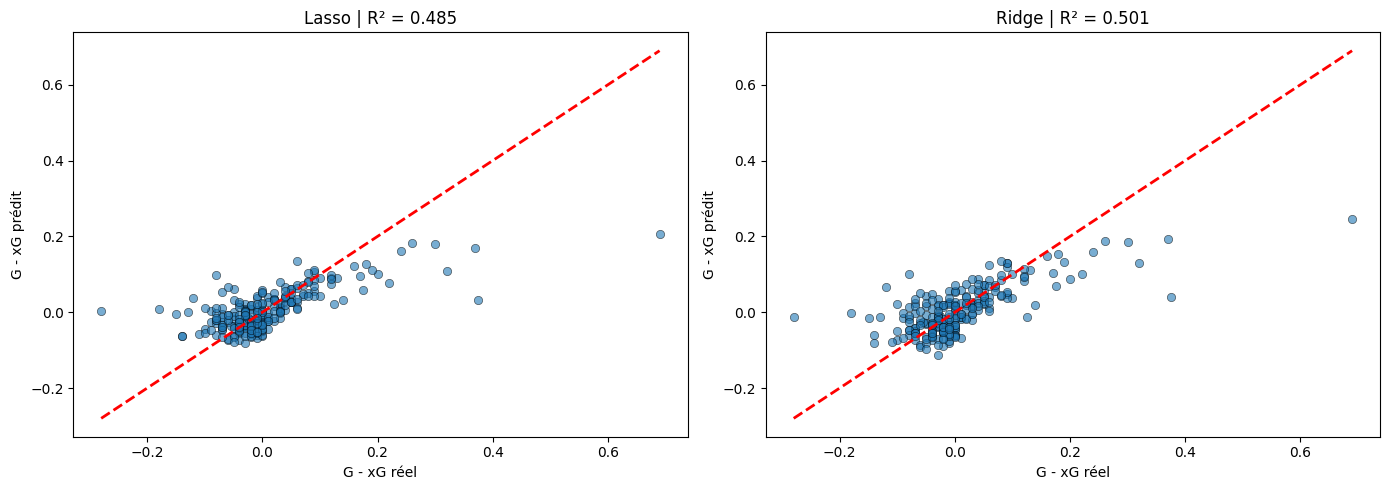

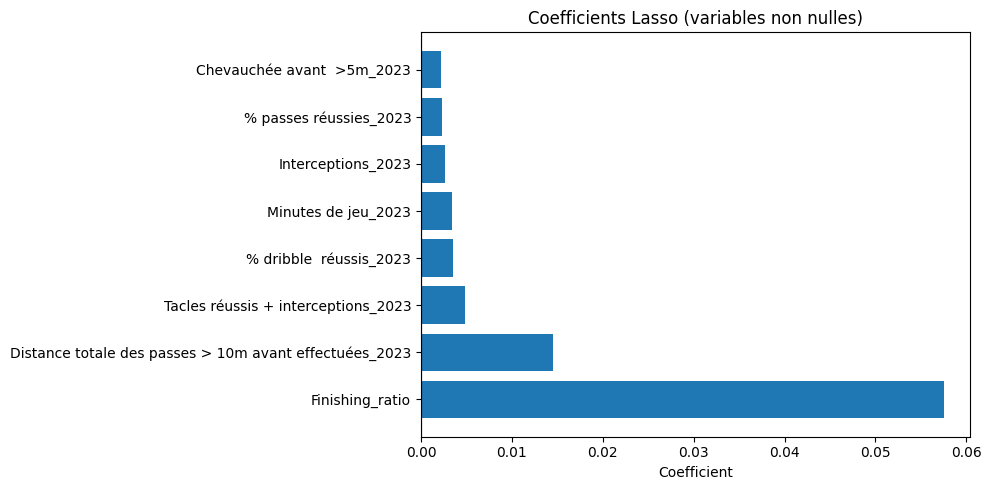

In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# =====================
# VARIABLE CIBLE
# =====================
df_goals=df_last2
df_goals["G_minus_xG_2023"] = df_goals["G_2023"] - df_goals["xG_2023"]

# =====================
# FEATURES
# =====================
features = [
    # Variables brutes complémentaires
    "Finishing_ratio",
    "% dribble  réussis_2023",
    "% duels aériens gagnés_2023",
    "Tirs_2023",
    "Tirs cadrés_2023",
    "Touches ballon en jeu_2023",
    "Chevauchée avant  >5m_2023",
    "Passes avant >10m_2023",
    "Distance totale des passes > 10m avant effectuées_2023",
    "% passes réussies_2023",
    "% passes longues réussies_2023",
    "Interceptions_2023",
    "Tacles réussis + interceptions_2023",
    "Blocs totaux_2023",
    "Dégagements_2023",
    "Dribbles subis perdus_2023",
    "Minutes de jeu_2023",
    "age_2023",
]

# =====================
# NETTOYAGE
# =====================
df_model = df_goals[features + ["G_minus_xG_2023", "player"]].dropna()

X = df_model[features]
y = df_model["G_minus_xG_2023"]

# =====================
# SPLIT + NORMALISATION
# =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================
# LASSO AVEC CV
# =====================
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# =====================
# RIDGE AVEC CV
# =====================
ridge = RidgeCV(cv=5)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# =====================
# COMPARAISON
# =====================
print("=" * 40)
print(f"LASSO  → R² : {r2_lasso:.3f} | RMSE : {rmse_lasso:.3f} | α : {lasso.alpha_:.4f}")
print(f"RIDGE  → R² : {r2_ridge:.3f} | RMSE : {rmse_ridge:.3f} | α : {ridge.alpha_:.4f}")
print("=" * 40)

# =====================
# COEFFICIENTS LASSO
# =====================
coef_df = pd.DataFrame({
    "feature": features,
    "coef_lasso": lasso.coef_,
    "coef_ridge": ridge.coef_
}).sort_values("coef_lasso", key=abs, ascending=False)

print("\nCoefficients :")
print(coef_df)

# =====================
# VISUALISATION
# =====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, r2 in zip(
    axes,
    [y_pred_lasso, y_pred_ridge],
    ["Lasso", "Ridge"],
    [r2_lasso, r2_ridge]
):
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors="k", linewidths=0.5)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--", lw=2)
    ax.set_xlabel("G - xG réel")
    ax.set_ylabel("G - xG prédit")
    ax.set_title(f"{title} | R² = {r2:.3f}")

plt.tight_layout()
plt.show()

# =====================
# VISUALISATION COEFFICIENTS
# =====================
coef_lasso_nonzero = coef_df[coef_df["coef_lasso"] != 0]

plt.figure(figsize=(10, 5))
plt.barh(coef_lasso_nonzero["feature"], coef_lasso_nonzero["coef_lasso"])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Coefficients Lasso (variables non nulles)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

### 🔹 2. Validation des indices

Vérifier la pertinence des indices créés grâce à un modèle de **régression logistique**.

L’objectif est de tester si ces indices permettent de **prédire correctement le poste d’un joueur** :

- Attaquant  
- Milieu  
- Défenseur  

La performance du modèle est évaluée à l’aide :

- d’une **matrice de confusion**
- de la **précision globale du modèle**

---

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



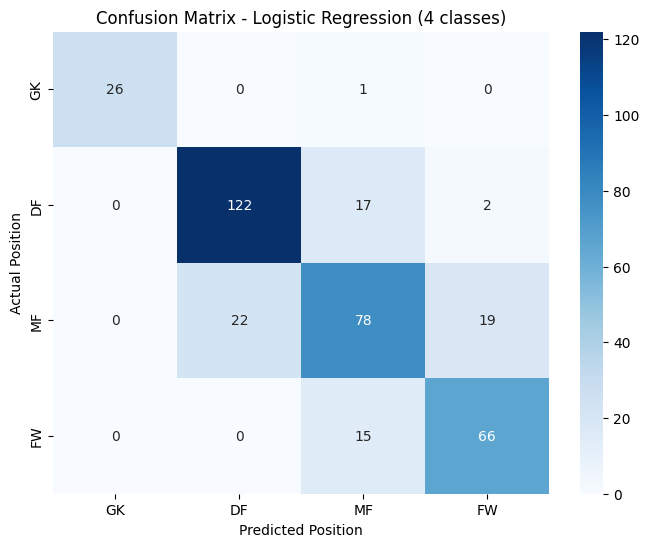

Logistic Regression (indices): Accuracy = 0.79


In [18]:
# ======================================
# Validation des indices avec Logistic Regression
# ======================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Features (indices)
# -------------------------------
indices_cols = [
    "Off Index",
    "PEIndex",
    "Playmaking Index",
    "Shooting Efficiency Index",
    "Offensive Contribution Index",
    "Clutch Performance Index",
    "Explosiveness Index",
    # Défensifs
    "Def Index",
    "Tackling Efficiency Index",
    "Duels Won Index",
    "Defensive Impact Index",
    # Milieux
    "Mil Index",
    "Passing Efficiency Index",
    "Strategic Play Index",
    "Forward Projection Index",
    # Général / endurance
    "Consistency Index"
]

# -------------------------------
# Création des 4 classes de postes
# -------------------------------
def map_position(pos):
    if pos == "GK":
        return "GK"
    elif pos.startswith("DF"):
        return "DF"
    elif pos.startswith("MF"):
        return "MF"
    elif pos.startswith("FW"):
        return "FW"
    else:
        return None

df_last2["pos_4classes"] = df_last2["pos"].apply(map_position)

# -------------------------------
# X et y
# -------------------------------
X = df_last2[indices_cols].fillna(0)
y = df_last2["pos_4classes"]

# -------------------------------
# Standardisation
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -------------------------------
# Logistic Regression
# -------------------------------
logreg = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs'
)

logreg.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_pred = logreg.predict(X_test)

# -------------------------------
# Confusion matrix
# -------------------------------
labels = ["GK", "DF", "MF", "FW"]

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (4 classes)")
plt.ylabel("Actual Position")
plt.xlabel("Predicted Position")
plt.show()

# -------------------------------
# Accuracy
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression (indices): Accuracy = {accuracy:.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



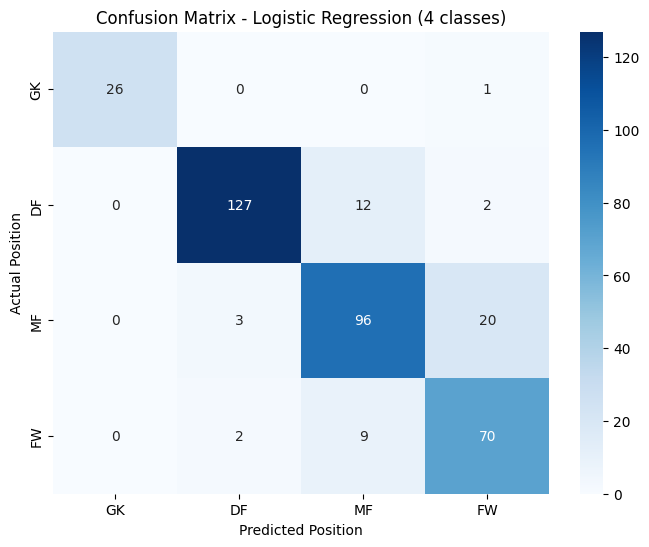

Logistic Regression (indices): Accuracy = 0.87


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Raw Features (indices)
# -------------------------------
raw_features = [
    '# 90 min jouées_2023',
    '% dribble  réussis_2023',
    '% duels aériens gagnés_2023',
    '% passes courtes réussies_2023',
    '% passes longues réussies_2023',
    '% passes moyennes réussies_2023',
    '% passes réussies_2023',
    'A_2023',
    'Blocs totaux_2023',
    'Chevauchée avant  >5m_2023',
    'Distance totale des passes > 10m avant effectuées_2023',
    'Dribbles subis perdus_2023',
    'Dégagements_2023',
    'Erreurs menant à un tir adverse_2023',
    'G_2023',
    'G+A_2023',
    'G+A-PK_2023',
    'G-PK_2023',
    'Interceptions_2023',
    'Minutes de jeu_2023',
    "Passes > 10m vers l'avant reçues_2023",
    'Passes avant >10m_2023',
    'Passes menant à un but_2023',
    'Passes reçues_2023',
    'Tacles réussis + interceptions_2023',
    'Tacles réussis qui gagnent la balle_2023',
    'Tirs_2023',
    'Tirs cadrés_2023',
    'Touches ballon en jeu_2023',
    'age_2023',
    'npxG_2023',
    'npxG+xAG_2023',
    'xAG_2023',
    'xG_2023',
    'xG / Tir_2023',
    'xG+xAG_2023'
]

# -------------------------------
# Création des 4 classes de postes
# -------------------------------
def map_position(pos):
    if pos == "GK":
        return "GK"
    elif pos.startswith("DF"):
        return "DF"
    elif pos.startswith("MF"):
        return "MF"
    elif pos.startswith("FW"):
        return "FW"
    else:
        return None

df_last2["pos_4classes"] = df_last2["pos"].apply(map_position)

# -------------------------------
# X et y
# -------------------------------
X = df_last2[raw_features].fillna(0)
y = df_last2["pos_4classes"]

# -------------------------------
# Standardisation
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -------------------------------
# Logistic Regression
# -------------------------------
logreg = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs'
)

logreg.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_pred = logreg.predict(X_test)

# -------------------------------
# Confusion matrix
# -------------------------------
labels = ["GK", "DF", "MF", "FW"]

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (4 classes)")
plt.ylabel("Actual Position")
plt.xlabel("Predicted Position")
plt.show()

# -------------------------------
# Accuracy
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression (indices): Accuracy = {accuracy:.2f}")

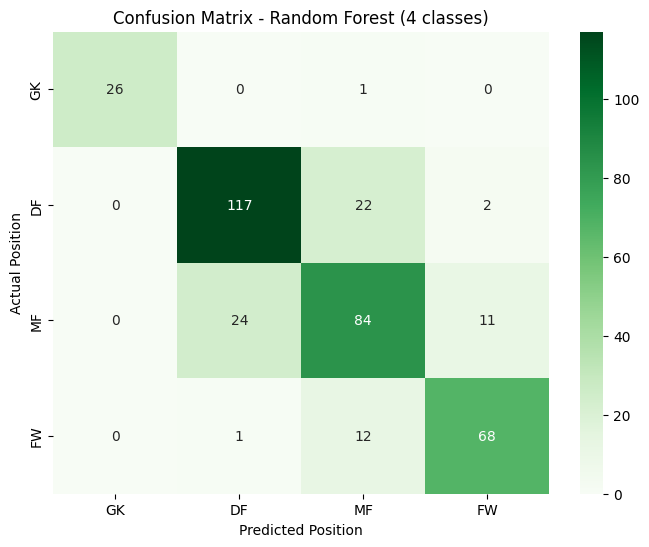

Random Forest (indices): Accuracy = 0.80


In [20]:
# ======================================
# Validation des indices avec Random Forest
# ======================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Features (indices)
# -------------------------------
indices_cols = [
    "Off Index",
    "PEIndex",
    "Playmaking Index",
    "Shooting Efficiency Index",
    "Offensive Contribution Index",
    "Clutch Performance Index",
    "Explosiveness Index",
    # Défensifs
    "Def Index",
    "Tackling Efficiency Index",
    "Duels Won Index",
    "Defensive Impact Index",
    # Milieux
    "Mil Index",
    "Passing Efficiency Index",
    "Strategic Play Index",
    "Forward Projection Index",
    # Général / endurance
    "Consistency Index"
]

# -------------------------------
# Création des 4 classes de postes
# -------------------------------
def map_position(pos):
    if pos == "GK":
        return "GK"
    elif pos.startswith("DF"):
        return "DF"
    elif pos.startswith("MF"):
        return "MF"
    elif pos.startswith("FW"):
        return "FW"
    else:
        return None

df_last2["pos_4classes"] = df_last2["pos"].apply(map_position)

# -------------------------------
# X et y
# -------------------------------
X = df_last2[indices_cols].fillna(0)
y = df_last2["pos_4classes"]

# -------------------------------
# Standardisation (pas obligatoire pour RF mais on garde cohérence)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -------------------------------
# Random Forest
# -------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_pred = rf.predict(X_test)

# -------------------------------
# Confusion matrix
# -------------------------------
labels = ["GK", "DF", "MF", "FW"]

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest (4 classes)")
plt.ylabel("Actual Position")
plt.xlabel("Predicted Position")
plt.show()

# -------------------------------
# Accuracy
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest (indices): Accuracy = {accuracy:.2f}")

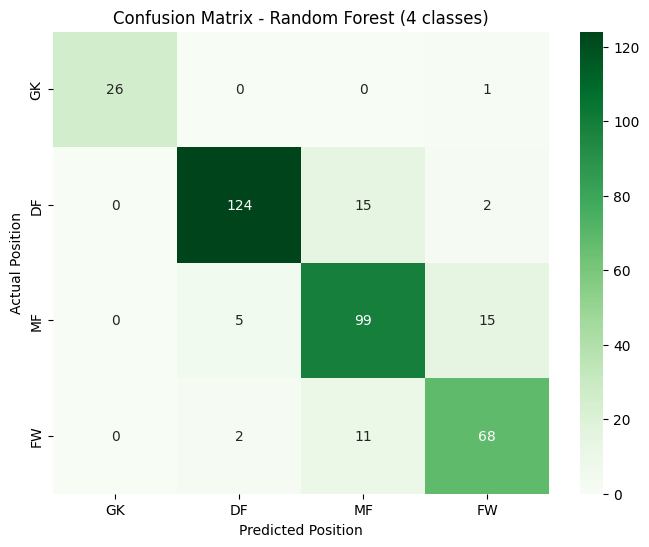

Random Forest (indices): Accuracy = 0.86


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Features (indices)
# -------------------------------
raw_features = [
    '# 90 min jouées_2023',
    '% dribble  réussis_2023',
    '% duels aériens gagnés_2023',
    '% passes courtes réussies_2023',
    '% passes longues réussies_2023',
    '% passes moyennes réussies_2023',
    '% passes réussies_2023',
    'A_2023',
    'Blocs totaux_2023',
    'Chevauchée avant  >5m_2023',
    'Distance totale des passes > 10m avant effectuées_2023',
    'Dribbles subis perdus_2023',
    'Dégagements_2023',
    'Erreurs menant à un tir adverse_2023',
    'G_2023',
    'G+A_2023',
    'G+A-PK_2023',
    'G-PK_2023',
    'Interceptions_2023',
    'Minutes de jeu_2023',
    "Passes > 10m vers l'avant reçues_2023",
    'Passes avant >10m_2023',
    'Passes menant à un but_2023',
    'Passes reçues_2023',
    'Tacles réussis + interceptions_2023',
    'Tacles réussis qui gagnent la balle_2023',
    'Tirs_2023',
    'Tirs cadrés_2023',
    'Touches ballon en jeu_2023',
    'age_2023',
    'npxG_2023',
    'npxG+xAG_2023',
    'xAG_2023',
    'xG_2023',
    'xG / Tir_2023',
    'xG+xAG_2023'
]


# -------------------------------
# Création des 4 classes de postes
# -------------------------------
def map_position(pos):
    if pos == "GK":
        return "GK"
    elif pos.startswith("DF"):
        return "DF"
    elif pos.startswith("MF"):
        return "MF"
    elif pos.startswith("FW"):
        return "FW"
    else:
        return None

df_last2["pos_4classes"] = df_last2["pos"].apply(map_position)

# -------------------------------
# X et y
# -------------------------------
X = df_last2[raw_features].fillna(0)
y = df_last2["pos_4classes"]

# -------------------------------
# Standardisation (pas obligatoire pour RF mais on garde cohérence)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -------------------------------
# Random Forest
# -------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_pred = rf.predict(X_test)

# -------------------------------
# Confusion matrix
# -------------------------------
labels = ["GK", "DF", "MF", "FW"]

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest (4 classes)")
plt.ylabel("Actual Position")
plt.xlabel("Predicted Position")
plt.show()

# -------------------------------
# Accuracy
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest (indices): Accuracy = {accuracy:.2f}")

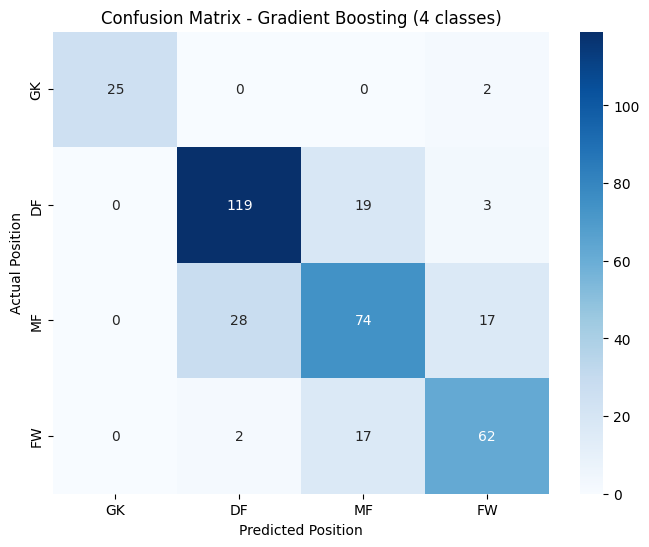

Gradient Boosting (indices): Accuracy = 0.76


In [22]:
# ======================================
# Validation des indices avec Gradient Boosting
# ======================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Features (indices)
# -------------------------------
indices_cols = [
    "Off Index",
    "PEIndex",
    "Playmaking Index",
    "Shooting Efficiency Index",
    "Offensive Contribution Index",
    "Clutch Performance Index",
    "Explosiveness Index",
    # Défensifs
    "Def Index",
    "Tackling Efficiency Index",
    "Duels Won Index",
    "Defensive Impact Index",
    # Milieux
    "Mil Index",
    "Passing Efficiency Index",
    "Strategic Play Index",
    "Forward Projection Index",
    # Général / endurance
    "Consistency Index"
]

# -------------------------------
# Mapping postes en 4 classes
# -------------------------------
def map_position(pos):
    if pos == "GK":
        return "GK"
    elif pos.startswith("DF"):
        return "DF"
    elif pos.startswith("MF"):
        return "MF"
    elif pos.startswith("FW"):
        return "FW"
    else:
        return None

df_last2["pos_4classes"] = df_last2["pos"].apply(map_position)

# -------------------------------
# X et y
# -------------------------------
X = df_last2[indices_cols].fillna(0)
y = df_last2["pos_4classes"]

# -------------------------------
# Standardisation
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -------------------------------
# Gradient Boosting
# -------------------------------
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_pred = gb.predict(X_test)

# -------------------------------
# Confusion matrix
# -------------------------------
labels = ["GK", "DF", "MF", "FW"]

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Gradient Boosting (4 classes)")
plt.ylabel("Actual Position")
plt.xlabel("Predicted Position")
plt.show()

# -------------------------------
# Accuracy
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Gradient Boosting (indices): Accuracy = {accuracy:.2f}")

### 🔹 3. Algorithme de scouting et recherche de joueurs similaires

Développer un **algorithme de scouting** basé sur la méthode **K-Nearest Neighbors (KNN)**.

À partir des indices calculés :

- chaque joueur est représenté dans un **espace statistique**
- une **distance euclidienne** permet de mesurer la similarité entre profils

L’algorithme permet ainsi :

- d’entrer le nom d’un joueur
- d’identifier les **20 joueurs les plus similaires statistiquement**
- d’explorer des profils comparables dans **différents championnats**


**Pourquoi KNN ?**

La méthode des K plus proches voisins (KNN) a été retenue car elle répond aux principales exigences de cette étude. Elle offre une forte interprétabilité, les joueurs suggérés étant simplement ceux dont le profil statistique est le plus proche du joueur de référence en termes de distance mathématique. De plus, les limites classiques du KNN sont ici atténuées : la taille du dataset reste modérée (environ 10 000 joueurs) et toutes les variables ont été préalablement normalisées, garantissant une comparaison équilibrée. Enfin, le modèle est flexible, puisqu’il permet d’adapter la similarité en sélectionnant des indices spécifiques selon les besoins du scouting.

In [23]:
# ==========================================
# KNN pour profils similaires de joueurs
# ==========================================

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


# -------------------------------
#  Colonnes à utiliser pour KNN
# -------------------------------
indices_cols = [
    #Offensifs
    "Off Index",
    "PEIndex",
    "Playmaking Index",
    "Shooting Efficiency Index",
    "Offensive Contribution Index",
    "Clutch Performance Index",
    "Explosiveness Index",
    "Passing Efficiency Index",
    # Général / endurance
    "Consistency Index"
]


df_knn = df_last2[["player", "pos", "team_2023", "league_2023", "age_2023", "nation_2023"] + indices_cols].copy()
df_knn[indices_cols] = df_knn[indices_cols].fillna(0)

# Réindexer df_knn pour que les indices correspondent à X_scaled
df_knn = df_knn.reset_index(drop=True)




# -------------------------------
# Standardisation
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_knn[indices_cols])

k_max = len(df_knn)
knn_model = NearestNeighbors(n_neighbors=k_max, metric="euclidean")
knn_model.fit(X_scaled)

import difflib
# -------------------------------
# KNN – fonction pour récupérer les k joueurs les plus proches
# -------------------------------
def get_similar_players(player_name, k=15):

    # Nettoyage entrée utilisateur
    player_name = player_name.strip()

    # Si le joueur n'existe pas exactement
    if player_name not in df_knn["player"].values:

        print(f"\n❌ '{player_name}' not found.\n")

        # Suggestions proches (tolérance aux fautes)
        suggestions = difflib.get_close_matches(
            player_name,
            df_knn["player"].values,
            n=7,
            cutoff=0.4
        )

        if len(suggestions) == 0:
            print("No close matches found.")
            return None

        print("🔎 Did you mean one of these?")
        for i, name in enumerate(suggestions):
            print(f"{i+1}. {name}")

        choice = input("\nEnter the number of the correct player (or press Enter to cancel): ")

        if choice.isdigit():
            player_name = suggestions[int(choice)-1]
            print(f"\n✅ Selected: {player_name}\n")
        else:
            return None

    # Index joueur
    idx = df_knn[df_knn["player"] == player_name].index[0]
    X_player = X_scaled[idx].reshape(1, -1)

    player_pos = df_knn.loc[idx, "pos"]

    # Recherche voisins
    distances, indices = knn_model.kneighbors(X_player)

    df_similar = df_knn.iloc[indices[0]].copy()
    df_similar["Euclidean_distance"] = distances[0]

    # Supprimer le joueur lui-même
    df_similar = df_similar[df_similar["player"] != player_name]

    # Filtrer même poste
    df_similar = df_similar[df_similar["pos"] == player_pos]

    # Garder k
    df_similar = df_similar.head(k)

    # Similarity score normalisé
    max_dist = distances[0].max()
    df_similar["Similarity_score"] = (
        100 * (1 - df_similar["Euclidean_distance"] / max_dist)
    )

    df_similar = df_similar.sort_values("Euclidean_distance")

    cols_order = [
        "player", "pos", "team_2023", "league_2023",
        "age_2023", "nation_2023"
    ] + indices_cols + ["Euclidean_distance", "Similarity_score"]

    df_similar = df_similar[cols_order].reset_index(drop=True)

    return df_similar


# DATA VIS
def display_similar_players_table(df_similar, player_name):
    # Trier par Similarity_score décroissant
    df_display = df_similar.sort_values("Similarity_score", ascending=False)

    # Colonnes à afficher
    display_cols = [
        "player", "pos", "team_2023", "league_2023", "age_2023", "nation_2023"
    ] + indices_cols + ["Similarity_score"]

    df_display = df_display[display_cols].reset_index(drop=True)

    # Ajouter un numéro de rang
    df_display.index = df_display.index + 1
    df_display.index.name = "Rank"

    # Arrondir les indices pour lisibilité
    for col in indices_cols + ["Similarity_score"]:
        df_display[col] = df_display[col].round(2)

    return df_display


# -------------------------------
# VERSION INTERACTIVE TERMINAL
# -------------------------------
player_input = input("🔎 Enter player name: ")
df_result = get_similar_players(player_input, k=15)

if df_result is not None:
    df_table = display_similar_players_table(df_result, player_input)
    print("\n🏆 Top 15 joueurs similaires :\n")
    display(df_table)


KeyboardInterrupt: Interrupted by user

In [ ]:
# ==========================================
# KNN pour profils similaires de joueurs
# ==========================================

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

indices_cols = [
    "Off Index",
    "PEIndex",
    "Playmaking Index",
    "Shooting Efficiency Index",
    "Offensive Contribution Index",
    "Clutch Performance Index",
    "Explosiveness Index",
    # Défensifs
    "Def Index",
    "Tackling Efficiency Index",
    "Duels Won Index",
    "Defensive Impact Index",
    "Mil Index",
    "Passing Efficiency Index",
    "Strategic Play Index",
    "Forward Projection Index",
    # Général / endurance
    "Consistency Index"
]


df_total = df_last2[["player", "pos", "team_2023", "league_2023", "age_2023", "nation_2023"] + indices_cols].copy()
df_total[indices_cols] = df_total[indices_cols].fillna(0)

X = df_total[indices_cols].values

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=0.9)  # garde 90% de la variance
X_pca = pca.fit_transform(X_scaled)

print("Nombre de composantes retenues :", pca.n_components_)

df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])

# On garde les infos joueurs
df_knn_pca = pd.concat(
    [df_total[["player", "pos", "team_2023", "league_2023", "age_2023", "nation_2023"]].reset_index(drop=True),
     df_pca],
    axis=1
)

k_max = len(df_knn_pca)
knn_model = NearestNeighbors(n_neighbors=k_max, metric="euclidean")
knn_model.fit(X_pca)

def get_similar_players(player_name, k=15):

    player_name = player_name.strip()

    # check existence
    if player_name not in df_knn_pca["player"].values:

        print(f"\n '{player_name}' not found.\n")

        suggestions = difflib.get_close_matches(
            player_name,
            df_knn_pca["player"].values,
            n=7,
            cutoff=0.4
        )

        if len(suggestions) == 0:
            print("No close matches found.")
            return None

        print("🔎 Suggestions:")
        for i, name in enumerate(suggestions):
            print(f"{i+1}. {name}")

        choice = input("\nChoose number (or Enter): ")

        if choice.isdigit():
            player_name = suggestions[int(choice)-1]
        else:
            return None

    # index
    idx = df_knn_pca[df_knn_pca["player"] == player_name].index[0]

    X_player = X_pca[idx].reshape(1, -1)

    player_pos = df_knn_pca.loc[idx, "pos"]

    # KNN
    distances, indices = knn_model.kneighbors(X_player)

    df_similar = df_knn_pca.iloc[indices[0]].copy()
    df_similar["Euclidean_distance"] = distances[0]

    # remove self
    df_similar = df_similar[df_similar["player"] != player_name]

    # same position
    df_similar = df_similar[df_similar["pos"] == player_pos]

    # top k
    df_similar = df_similar.sort_values("Euclidean_distance").head(k)

    # similarity score stable
    max_dist = np.percentile(distances[0], 95)

    df_similar["Similarity_score"] = 100 * (
        1 - df_similar["Euclidean_distance"] / max_dist
    )

    #  MERGE BACK ORIGINAL INDICES (IMPORTANT)
    df_similar = df_similar.merge(
        df_total[["player"] + indices_cols],
        on="player",
        how="left"
    )

    return df_similar

# DATA VIS
def display_similar_players_table(df_similar):

    df_display = df_similar.sort_values("Similarity_score", ascending=False)

    display_cols = [
        "player", "pos", "team_2023", "league_2023",
        "age_2023", "nation_2023"
    ] + ["Similarity_score"]

    df_display = df_display[display_cols].reset_index(drop=True)

    df_display.index = df_display.index + 1
    df_display.index.name = "Rank"

    for col in ["Similarity_score"]:
        df_display[col] = df_display[col].round(2)

    return df_display


# -------------------------------
# VERSION INTERACTIVE TERMINAL
# -------------------------------
player_input = input("🔎 Enter player name: ")

df_result = get_similar_players(player_input, k=15)

if df_result is not None:
    df_table = display_similar_players_table(df_result)
    print("\n Top 15 similar players:\n")
    display(df_table)

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


# -------------------------------
#  Colonnes à utiliser pour KNN
# -------------------------------
indices_cols = [
    # Défensifs
    "Def Index",
    "Tackling Efficiency Index",
    "Duels Won Index",
    "Defensive Impact Index",
    "Passing Efficiency Index",
    "Strategic Play Index",
    "Forward Projection Index",
    # Général / endurance
    "Consistency Index"
]

df_knn = df_last2[["player", "pos", "team_2023", "league_2023", "age_2023", "nation_2023"] + indices_cols].copy()


df_knn = df_last2[["player", "pos", "team_2023", "league_2023", "age_2023", "nation_2023"] + indices_cols].copy()
df_knn[indices_cols] = df_knn[indices_cols].fillna(0)

# Réindexer df_knn pour que les indices correspondent à X_scaled
df_knn = df_knn.reset_index(drop=True)

# -------------------------------
# Standardisation
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_knn[indices_cols])

k_max = len(df_knn)
knn_model = NearestNeighbors(n_neighbors=k_max, metric="euclidean")
knn_model.fit(X_scaled)

import difflib
# -------------------------------
# KNN – fonction pour récupérer les k joueurs les plus proches
# -------------------------------
def get_similar_players(player_name, k=20):

    # Nettoyage entrée utilisateur
    player_name = player_name.strip()

    # Si le joueur n'existe pas exactement
    if player_name not in df_knn["player"].values:

        print(f"\n '{player_name}' not found.\n")

        # Suggestions proches (tolérance aux fautes)
        suggestions = difflib.get_close_matches(
            player_name,
            df_knn["player"].values,
            n=7,
            cutoff=0.4
        )

        if len(suggestions) == 0:
            print("No close matches found.")
            return None

        print("🔎 Did you mean one of these?")
        for i, name in enumerate(suggestions):
            print(f"{i+1}. {name}")

        choice = input("\nEnter the number of the correct player (or press Enter to cancel): ")

        if choice.isdigit():
            player_name = suggestions[int(choice)-1]
            print(f"\n Selected: {player_name}\n")
        else:
            return None

    # Index joueur
    idx = df_knn[df_knn["player"] == player_name].index[0]
    X_player = X_scaled[idx].reshape(1, -1)

    player_pos = df_knn.loc[idx, "pos"]

    # Recherche voisins
    distances, indices = knn_model.kneighbors(X_player)

    df_similar = df_knn.iloc[indices[0]].copy()
    df_similar["Euclidean_distance"] = distances[0]

    # Supprimer le joueur lui-même
    df_similar = df_similar[df_similar["player"] != player_name]

    # Filtrer même poste
    df_similar = df_similar[df_similar["pos"] == player_pos]

    # Garder k
    df_similar = df_similar.head(k)

    # Similarity score normalisé
    max_dist = distances[0].max()
    df_similar["Similarity_score"] = (
        100 * (1 - df_similar["Euclidean_distance"] / max_dist)
    )

    df_similar = df_similar.sort_values("Euclidean_distance")

    cols_order = [
        "player", "pos", "team_2023", "league_2023",
        "age_2023", "nation_2023"
    ] + indices_cols + ["Euclidean_distance", "Similarity_score"]

    df_similar = df_similar[cols_order].reset_index(drop=True)

    return df_similar


# -------------------------------
# VERSION INTERACTIVE TERMINAL
# -------------------------------
player_input = input("🔎 Enter player name: ")

df_result = get_similar_players(player_input, k=20)

if df_result is not None:
    print("\n🏆 Top 20 most similar players:\n")
    print(df_result)

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


# -------------------------------
#  Colonnes à utiliser pour KNN
# -------------------------------
indices_cols = [
    #Millieu
    "Mil Index",
    "Passing Efficiency Index",
    "Strategic Play Index",
    "Forward Projection Index",

    #Contr Offensive
    "Explosiveness Index",
    "Playmaking Index",
    "Shooting Efficiency Index",

    #Def
    "Tackling Efficiency Index",
    "Duels Won Index",

    # Général / endurance
    "Consistency Index"
]

df_knn = df_last2[["player", "pos", "team_2023", "league_2023", "age_2023", "nation_2023"] + indices_cols].copy()


df_knn = df_last2[["player", "pos", "team_2023", "league_2023", "age_2023", "nation_2023"] + indices_cols].copy()
df_knn[indices_cols] = df_knn[indices_cols].fillna(0)

# Réindexer df_knn pour que les indices correspondent à X_scaled
df_knn = df_knn.reset_index(drop=True)

# -------------------------------
# Standardisation
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_knn[indices_cols])

k_max = len(df_knn)
knn_model = NearestNeighbors(n_neighbors=k_max, metric="euclidean")
knn_model.fit(X_scaled)

import difflib
# -------------------------------
# KNN – fonction pour récupérer les k joueurs les plus proches
# -------------------------------
def get_similar_players(player_name, k=20):

    # Nettoyage entrée utilisateur
    player_name = player_name.strip()

    # Si le joueur n'existe pas exactement
    if player_name not in df_knn["player"].values:

        print(f"\n❌ '{player_name}' not found.\n")

        # Suggestions proches (tolérance aux fautes)
        suggestions = difflib.get_close_matches(
            player_name,
            df_knn["player"].values,
            n=7,
            cutoff=0.4
        )

        if len(suggestions) == 0:
            print("No close matches found.")
            return None

        print("🔎 Did you mean one of these?")
        for i, name in enumerate(suggestions):
            print(f"{i+1}. {name}")

        choice = input("\nEnter the number of the correct player (or press Enter to cancel): ")

        if choice.isdigit():
            player_name = suggestions[int(choice)-1]
            print(f"\n✅ Selected: {player_name}\n")
        else:
            return None

    # Index joueur
    idx = df_knn[df_knn["player"] == player_name].index[0]
    X_player = X_scaled[idx].reshape(1, -1)

    player_pos = df_knn.loc[idx, "pos"]

    # Recherche voisins
    distances, indices = knn_model.kneighbors(X_player)

    df_similar = df_knn.iloc[indices[0]].copy()
    df_similar["Euclidean_distance"] = distances[0]

    # Supprimer le joueur lui-même
    df_similar = df_similar[df_similar["player"] != player_name]

    # Filtrer même poste
    df_similar = df_similar[df_similar["pos"] == player_pos]

    # Garder k
    df_similar = df_similar.head(k)

    # Similarity score normalisé
    max_dist = distances[0].max()
    df_similar["Similarity_score"] = (
        100 * (1 - df_similar["Euclidean_distance"] / max_dist)
    )

    df_similar = df_similar.sort_values("Euclidean_distance")

    cols_order = [
        "player", "pos", "team_2023", "league_2023",
        "age_2023", "nation_2023"
    ] + indices_cols + ["Euclidean_distance", "Similarity_score"]

    df_similar = df_similar[cols_order].reset_index(drop=True)

    return df_similar


# -------------------------------
# VERSION INTERACTIVE TERMINAL
# -------------------------------
player_input = input("🔎 Enter player name: ")

df_result = get_similar_players(player_input, k=20)

if df_result is not None:
    print("\n🏆 Top 20 most similar players:\n")
    print(df_result)

In [ ]:
def compute_indices(df, year):

    # -------------------------------
    # UEFA coefficient
    # -------------------------------

    coeff_dict = {
        "ENG-Premier League": 10.4303,
        "ITA-Serie A": 9.0284,
        "ESP-La Liga": 8.9489,
        "GER-Bundesliga": 8.6624,
        "FRA-Ligue 1": 6.6831,
    }

    df[f"uefa_{year}"] = df[f"league_{year}"].map(coeff_dict)

    # Removed: df = df[df["Minutes de jeu_2023"] >= 900.0].copy()

    # =====================
    # VARIABLES DE BASE
    # =====================
    df[f"Finishing_ratio_{year}"] = (
        df[f"G-PK_{year}"] / (df[f"Tirs_{year}"] + 1)
    ) * 100

    df[f"Goals_total_{year}"] = df[f"G_{year}"] * df[f"# 90 min jouées_{year}"]

    df[f"Shots_total_{year}"] = df[f"Tirs_{year}"] * df[f"# 90 min jouées_{year}"]

    df[f"Goal_Shot_ratio_{year}"] = (
        df[f"Goals_total_{year}"] / (df[f"Shots_total_{year}"] + 1)
    )

    # =====================
    # OFF INDEX
    # =====================
    OSI = (
        df[f"G_{year}"] * 2
        + df[f"xG_{year}"] * 1.2
        + df[f"Tirs cadrés_{year}"] * 1.8
        + df[f"Passes menant à un but_{year}"] * 0.5
        + df[f"uefa_{year}"]
    )

    df[f"Off_Index_{year}"] = 100 * (OSI - OSI.min()) / (OSI.max() - OSI.min())

    # =====================
    # DEF INDEX
    # =====================
    DSI = (
        df[f"Tacles réussis + interceptions_{year}"] * 3
        + df[f"Interceptions_{year}"] * 2
        + df[f"Blocs totaux_{year}"] * 2
        - df[f"Erreurs menant à un tir adverse_{year}"] * 3
        + df[f"uefa_{year}"]
    )

    df[f"Def_Index_{year}"] = 100 * (DSI - DSI.min()) / (DSI.max() - DSI.min())

    # =====================
    # MILIEU INDEX
    # =====================
    MSI = (
        df[f"A_{year}"] * 2
        + df[f"G_{year}"] * 0.5
        + df[f"% passes réussies_{year}"] * 3
        + df[f"Passes menant à un but_{year}"] * 2
        + df[f"Passes avant >10m_{year}"] * 0.5
        + df[f"% passes longues réussies_{year}"] * 0.6
        + df[f"xAG_{year}"]
        + df[f"% dribble  réussis_{year}"] * 0.5
        + df[f"Interceptions_{year}"] * 1.8
        + df[f"Tacles réussis qui gagnent la balle_{year}"] * 1.5
        + df[f"Dégagements_{year}"]
        + df[f"Blocs totaux_{year}"] * 1.5
        + df[f"Minutes de jeu_{year}"] * 0.05
        + df[f"Touches ballon en jeu_{year}"]
        + df[f"Chevauchée avant  >5m_{year}"] * 0.5
        + df[f"Distance totale des passes > 10m avant effectuées_{year}"] * 0.5
        + df[f"uefa_{year}"]
    )

    df[f"Mil_Index_{year}"] = 100 * (MSI - MSI.min()) / (MSI.max() - MSI.min())

    # =====================
    # Passing Efficiency
    # =====================
    PEI = (
        df[f"% passes réussies_{year}"] * 0.7
        + df[f"Passes menant à un but_{year}"] * 0.2
        + df[f"A_{year}"]
        + df[f"uefa_{year}"]
    )

    df[f"Passing_Efficiency_Index_{year}"] = 100 * (PEI - PEI.min()) / (PEI.max() - PEI.min())

    # =====================
    # Strategic Play
    # =====================
    SPI = (
        df[f"Passes menant à un but_{year}"] * 0.2
        + df[f"% passes réussies_{year}"]
        + df[f"Tacles réussis + interceptions_{year}"] * 1.2
        + df[f"% duels aériens gagnés_{year}"]
        + df[f"uefa_{year}"]
    )

    df[f"Strategic_Play_Index_{year}"] = 100 * (SPI - SPI.min()) / (SPI.max() - SPI.min())

    # =====================
    # Forward Projection
    # =====================
    FPI = (
        df[f"% passes longues réussies_{year}"] * 1.2
        + df[f"% dribble  réussis_{year}"]
        + df[f"Chevauchée avant  >5m_{year}"] * 1.5
        + df[f"Distance totale des passes > 10m avant effectuées_{year}"] * 1.3
        + df[f"Passes avant >10m_{year}"] * 1.5
        + df[f"uefa_{year}"]
    )

    df[f"Forward_Projection_Index_{year}"] = 100 * (FPI - FPI.min()) / (FPI.max() - FPI.min())

    # =====================
    # Consistency
    # =====================
    CI = (
        df[f"# 90 min jouées_{year}"] * 1.5
        + df[f"Minutes de jeu_{year}"]
    )

    df[f"Consistency_Index_{year}"] = 100 * (CI - CI.min()) / (CI.max() - CI.min())

    return df

# Create a working copy of df_final to add all computed indices
df_prog = df_final.copy()

# Apply the compute_indices function for each year sequentially to accumulate all yearly indices
df_prog = compute_indices(df_prog, 2020)
df_prog = compute_indices(df_prog, 2022)
df_prog = compute_indices(df_prog, 2023)

indices = [
    "Off_Index",
    "Def_Index",
    "Mil_Index",
    "Passing_Efficiency_Index",
    "Strategic_Play_Index",
    "Forward_Projection_Index",
    "Consistency_Index"
]

for idx in indices:
    df_prog[f"{idx}_delta_global"] = df_prog[f"{idx}_2023"] - df_prog[f"{idx}_2020"]


progression_features = [
    "Off_Index_delta_global",
    "Def_Index_delta_global",
    "Mil_Index_delta_global",
    "Passing_Efficiency_Index_delta_global",
    "Strategic_Play_Index_delta_global",
    "Forward_Projection_Index_delta_global",
    "Consistency_Index_delta_global"
]



df_prog[df_prog["player"] == "Pedri"]
from sklearn.impute import SimpleImputer

df_prog_filtered = df_prog.dropna(subset=progression_features)

df_young = df_prog_filtered[df_prog_filtered["Minutes de jeu_2023"] >= 500.0]

df_young = df_prog_filtered[df_prog_filtered["age_2023"] <= 20].copy()

pedri = df_prog_filtered[df_prog_filtered["player"] == "Pedri"]

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

scaler = StandardScaler()

X = df_young[progression_features]
X_scaled = scaler.fit_transform(X)

X_pedri = scaler.transform(pedri[progression_features])

df_young["distance_to_pedri"] = euclidean_distances(X_scaled, X_pedri).flatten()

top20 = (
     df_young
     .sort_values("distance_to_pedri")
    .head(6)
 )

#top20[["player","pos", "age_2020", "age_2023", "distance_to_pedri"] + progression_features]
df_young


Lasso → R² : 0.656 | RMSE : 0.698
Linear Regression → R² : 0.662 | RMSE : 0.692
Random Forest → R² : 0.629 | RMSE : 0.725
XGBoost → R² : 0.642 | RMSE : 0.713

 Top 20 joueurs sous-évalués :
                player  age_2023  valeur_reelle  valeur_predite    ecart_pct
939        Diego López      21.0      7050000.0    1.468883e+08  1983.521606
3981           Vitinha      23.0     32000000.0    2.898242e+08   805.700490
3482  Ryan Gravenberch      21.0     35000000.0    2.587245e+08   639.212850
3633   Serhou Guirassy      27.0     40000000.0    1.946750e+08   386.687603
3145       Pascal Groß      32.0      8000000.0    3.213025e+07   301.628175
2912      Nadiem Amiri      26.0      7000000.0    2.686564e+07   283.794819
3603     Sergi Cardona      24.0      6000000.0    2.192088e+07   265.348043
3402        Robin Hack      24.0      8000000.0    2.857063e+07   257.132826
3612    Sergio Arribas      21.0     10000000.0    3.471334e+07   247.133389
1789       Jeremy Doku      21.0     650

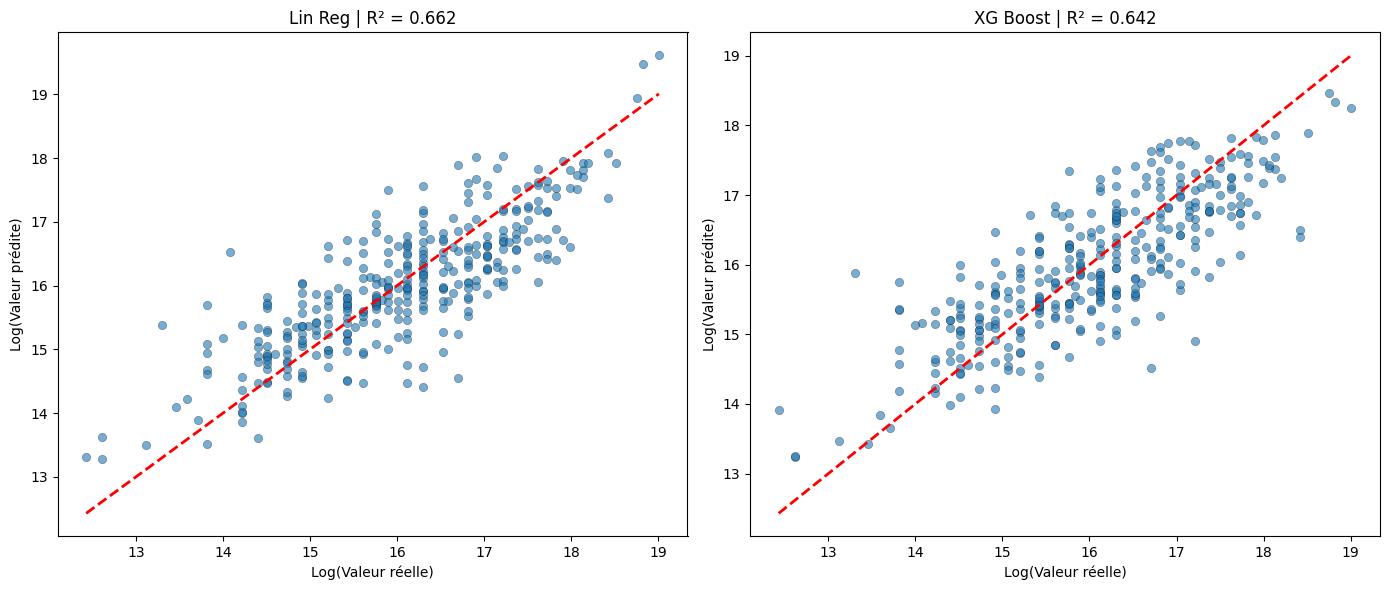

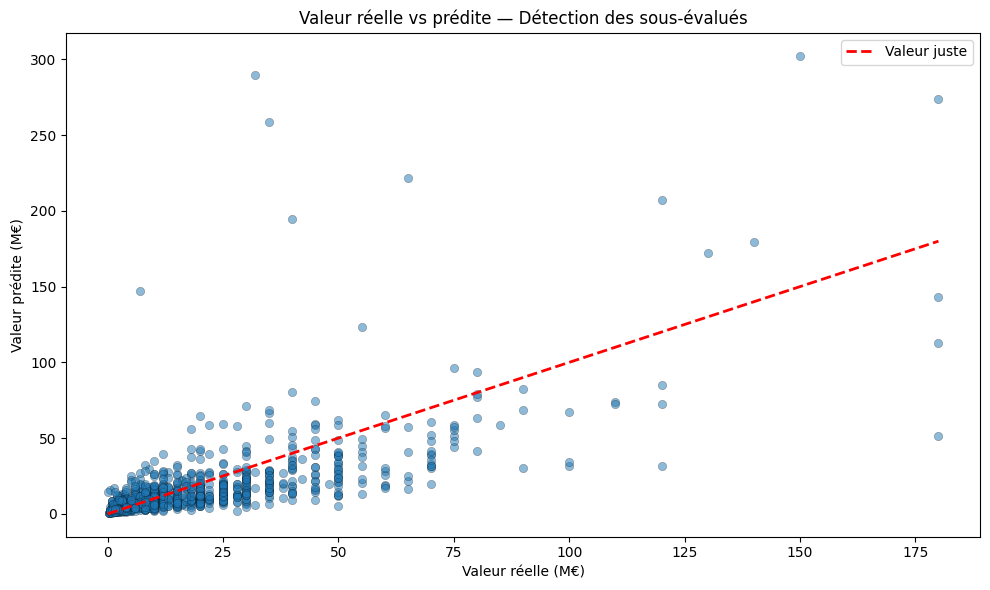

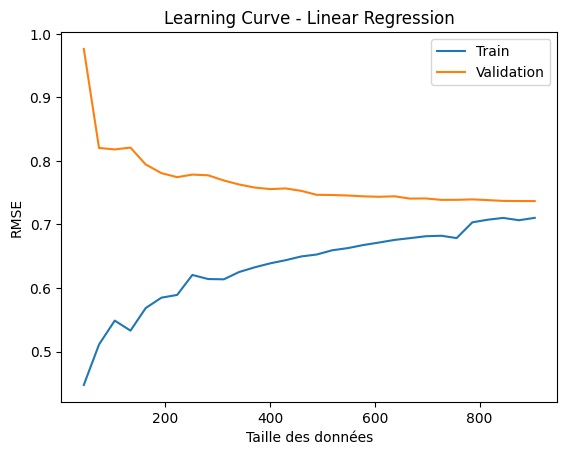

In [25]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


# =====================
# VARIABLE CIBLE
# =====================
df_last2["log_valeur"] = np.log1p(df_last2["Valeur marchande (euros)_2023"])

# =====================
# FEATURES
# =====================
indices_cols = [
    "Off Index",
    "PEIndex",
    "Playmaking Index",
    "Shooting Efficiency Index",
    "Offensive Contribution Index",
    "Clutch Performance Index",
    "Explosiveness Index",
    "Def Index",
    "Tackling Efficiency Index",
    "Duels Won Index",
    "Defensive Impact Index",
    "Mil Index",
    "Passing Efficiency Index",
    "Strategic Play Index",
    "Forward Projection Index",
    "Consistency Index"
]

# =====================
# NETTOYAGE
# =====================
df_valeur = df_last2[indices_cols + ["log_valeur", "player", "pos", "age_2023"]].dropna()

df_valeur = pd.get_dummies(df_valeur, columns=["pos"], drop_first=True)

X = df_valeur.drop(columns=["log_valeur","player"])
y = df_valeur["log_valeur"]

# =====================
# SPLIT + NORMALISATION
# =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================
# LINEAR REGRESSION
# =====================
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred_linreg = linreg.predict(X_test_scaled)

# =====================
# LASSO
# =====================
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# =====================
# RANDOM FOREST
# =====================
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# =====================
# XG BOOST
# =====================
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)


# =====================
# COMPARAISON
# =====================
for name, y_pred in [("Lasso", y_pred_lasso), ("Linear Regression", y_pred_linreg), ("Random Forest", y_pred_rf),("XGBoost", y_pred_xgb)]:
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name} → R² : {r2:.3f} | RMSE : {rmse:.3f}")

# =====================
# DETECTION SOUS-EVALUES
# =====================
from sklearn.model_selection import cross_val_predict

# normalisation sur tout le dataset
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# nouveau modèle (indépendant du train/test)
rf_full = LinearRegression()

# prédictions out-of-sample
y_pred_oof = cross_val_predict(
    rf_full,
    X_scaled_full,
    y,
    cv=5
)

df_valeur["valeur_predite_log"] = y_pred_oof

df_valeur["valeur_predite"] = np.expm1(df_valeur["valeur_predite_log"])
df_valeur["valeur_reelle"] = np.expm1(df_valeur["log_valeur"])
df_valeur["ecart"] = df_valeur["valeur_predite"] - df_valeur["valeur_reelle"]
df_valeur["ecart_pct"] = (df_valeur["ecart"] / df_valeur["valeur_reelle"]) * 100

# =====================
# TOP SOUS-EVALUES
# =====================
top_sous_evalues = (
    df_valeur[
        (df_valeur["valeur_reelle"] >= 5_000_000)
    ]
    .sort_values("ecart_pct", ascending=False)
    .head(20)
)[["player", "age_2023", "valeur_reelle", "valeur_predite", "ecart_pct"]]

print("\n Top 20 joueurs sous-évalués :")
print(top_sous_evalues.to_string())

# =====================
# VISUALISATION SCATTER PREDIT VS REEL
# =====================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_linreg, y_pred_xgb],
    ["Lin Reg", "XG Boost"]
):
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors="k", linewidths=0.3)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--", lw=2)
    ax.set_xlabel("Log(Valeur réelle)")
    ax.set_ylabel("Log(Valeur prédite)")
    ax.set_title(f"{title} | R² = {r2_score(y_test, y_pred):.3f}")

plt.tight_layout()
plt.show()

# =====================
# VISUALISATION SOUS-EVALUES VS SUREVALUES
# =====================
plt.figure(figsize=(10, 6))
plt.scatter(
    df_valeur["valeur_reelle"] / 1e6,
    df_valeur["valeur_predite"] / 1e6,
    alpha=0.5, edgecolors="k", linewidths=0.3
)
plt.plot(
    [0, df_valeur["valeur_reelle"].max() / 1e6],
    [0, df_valeur["valeur_reelle"].max() / 1e6],
    "r--", lw=2, label="Valeur juste"
)
plt.xlabel("Valeur réelle (M€)")
plt.ylabel("Valeur prédite (M€)")
plt.title("Valeur réelle vs prédite — Détection des sous-évalués")
plt.legend()
plt.tight_layout()
plt.show()


from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(),
    X_scaled_full,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.05, 1.0, 30)
)

train_rmse = np.sqrt(-train_scores)
val_rmse = np.sqrt(-val_scores)

plt.plot(train_sizes, train_rmse.mean(axis=1), label="Train")
plt.plot(train_sizes, val_rmse.mean(axis=1), label="Validation")
plt.xlabel("Taille des données")
plt.ylabel("RMSE")
plt.legend()
plt.title("Learning Curve - Linear Regression")
plt.show()